# 4장 — 단순 네트워크에서 다중 소스 통합으로

| | |
| --- | --- |
| **책** | Alessandro Negro 외, *Knowledge Graphs and LLMs in Action* (Manning, 2025) **4장** |
| **해설 원본** | [04_..._ko_explained.md 열기](../../04_from_simple_networks_to_multisource_integration_ko_explained.md) |
| **이 폴더** | [tasks.py](./tasks.py) · [listings/](./listings) · [importer/](./importer) · [analysis/](./analysis) |
| **원서 저장소** | [alenegro81/.../chapters/ch04 열기](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch04) |
| **리스팅 번호** | **오프셋 0** — 책 번호 = 파일 번호 (예: 책 4.9 = 파일 `4.9 Run WCC on the PPI Network`). 3장은 −3 이었다. 챕터마다 다르므로 복사하면 안 된다 |

---

3장은 온톨로지 **하나** 로 지식 그래프를 지었다. 4장은 **이미 그래프로 다루기 좋은 형태로 제공되는 여러 구조화 소스** 를 합친다. 그래서 초점이 "어떻게 모델링하고, 어떻게 통합하고, 어떻게 분석하나"로 옮겨간다.

| 절 | 내용 | 데이터베이스 | 실습 |
| --- | --- | --- | --- |
| 4.1 | 생명의학 KG 가 푸는 문제 유형 | — | — |
| 4.2 | 다중 오믹스: PPI + 질병 네트워크 | `ppi` | 실습 4-A |
| 4.3 | 제약: 약물 재활용과 DWPC | `hetionet` | 실습 4-B, 4-C |
| 4.4 | 임상: 정밀 의료와 CKG | `ckg` (선택) | — |
| — | 요약·용어·실측 대비 | — | — |

> **한 문장 요약** — 여러 생명의학 소스를 하나의 그래프로 합친 뒤, **커뮤니티 탐지** 로 전체 구조를 보고, **질병 경로 지표**(가장 큰 컴포넌트·밀도·전도도)로 부분 구조를 재고, **DWPC 메타경로** 로 흔한 노드에 속지 않는 순위를 뽑아 약물 재활용 후보를 찾는다.

이 장에서 **LLM은 보조 역할만** 한다. 소스가 CSV·관계형 DB·API 처럼 이미 구조화돼 있으므로 전통적 데이터 통합 기법이 주력이고, LLM 은 4.3.2 에서 순위표를 사람이 읽을 서사로 바꾸는 데만 쓰인다. 데이터가 이미 정돈돼 있으면 지어낼 위험이 있는 달변가에게 통합을 맡길 이유가 없다.

## 4.1 생명의학 지식 그래프가 푸는 문제

해설판은 다섯 가지 질문으로 장을 연다. 모두 "흩어진 사실을 노드와 관계로 엮어두면 겉으로 드러나지 않던 연결을 그래프 위에서 추론할 수 있다"는 하나의 전제를 공유한다.

- 질병과 단백질 사이 이미 알려진 관계에서 출발해 **새로운 연결** 을 발견할 수 있을까

- 값비싼 시험관 실험 없이 마이크로 RNA 와 질병의 의미 있는 관계를 찾아낼 수 있을까

- 셀리악병 같은 특정 질병에 관여하는 **핵심 과정** 은 무엇일까

- 수년의 연구 없이 기존 약물의 **새로운 용도(repurposing)** 를 찾아낼 수 있을까

- 환자 개개인의 정보를 활용하는 **정밀 의료** 를 어떻게 뒷받침할까

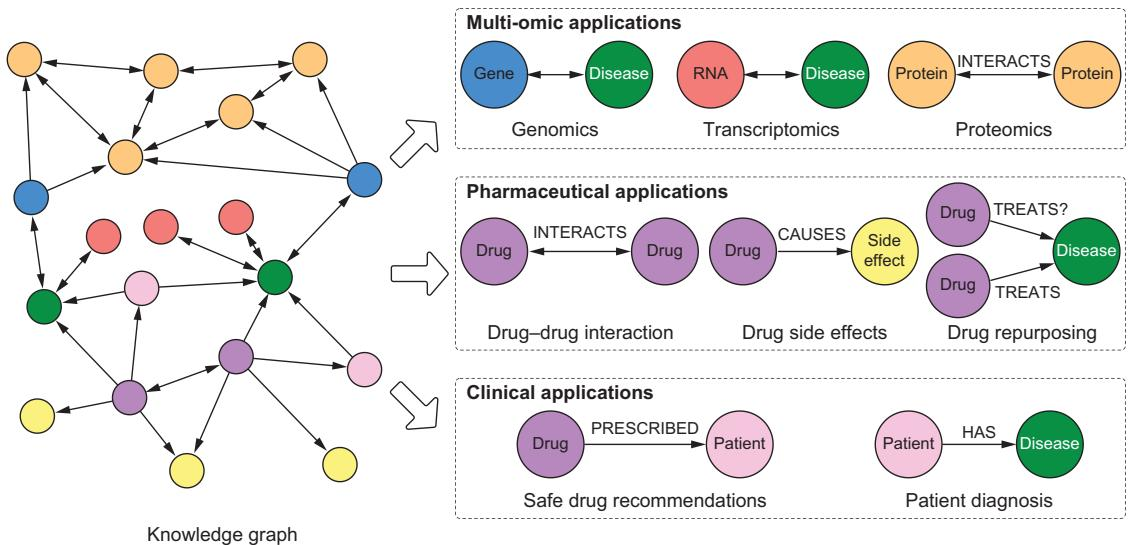

*그림 4.1 — 비즈니스 목표별로 묶은 지식 그래프의 주요 생명의학 응용 유형. 이들은 공통으로 쓰는 데이터 소스가 많다. 이 노트북의 4.2·4.3·4.4 절이 각각 다중 오믹스·제약·임상 응용에 대응한다.*

각 응용은 서로 다른 비즈니스 목표를 갖고, **CRISP-DM** 에 따라 서로 다른 소스로 구축된다. 이 장의 학습 포인트는 "지식 그래프에 넣을 데이터 소스를 어떻게 고르고, 그 정보가 원하는 작업을 해내기에 충분한지 어떻게 판단하나"다.

## 4.2 다중 오믹스 — 유전체에서 단백질까지

**다중 오믹스(multi-omic)** 는 유전체·전사체·단백질체처럼 여러 "오믹스" 데이터셋을 함께 쓰는 접근이다. 분자생물학에서 접미사 **-ome** 은 "전체 총합"을 뜻한다.

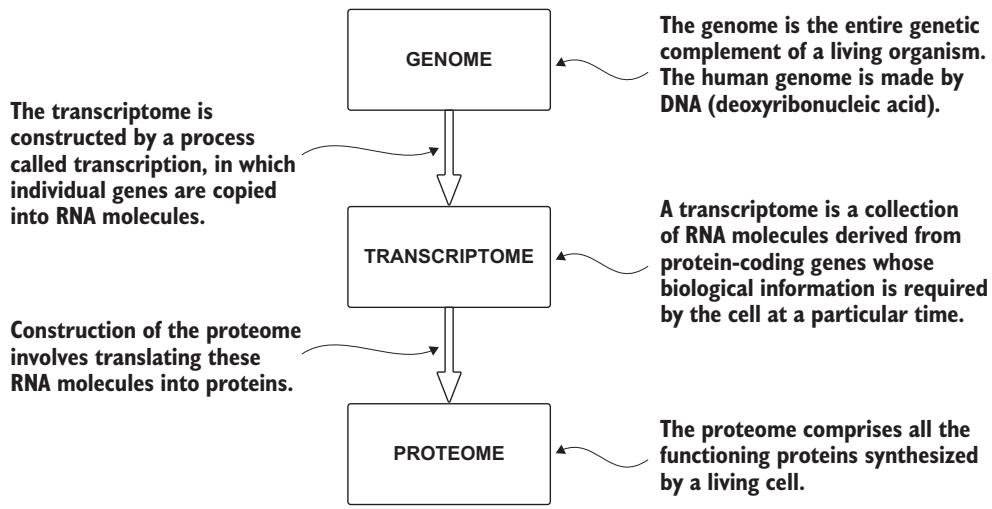

*그림 4.2 — 생명의학 KG 가 쓰는 세 가지 주요 오믹스 데이터 유형. 유전체(DNA) · 전사체(RNA) · 단백질체(단백질)는 전사(transcription)와 번역(translation)으로 생물학적으로 연결된다.*

| 용어 | 뜻 |
| --- | --- |
| **유전체 (genome)** | 생물의 유전 정보 전체. 대부분 DNA, 일부 바이러스는 RNA |
| **전사체 (transcriptome)** | 단백질체 합성을 지시하는 RNA 분자들의 집합. **전사** 로 만들어진다 |
| **단백질체 (proteome)** | 세포가 합성한 기능성 단백질 전체. 유전체 발현의 최종 산물 |

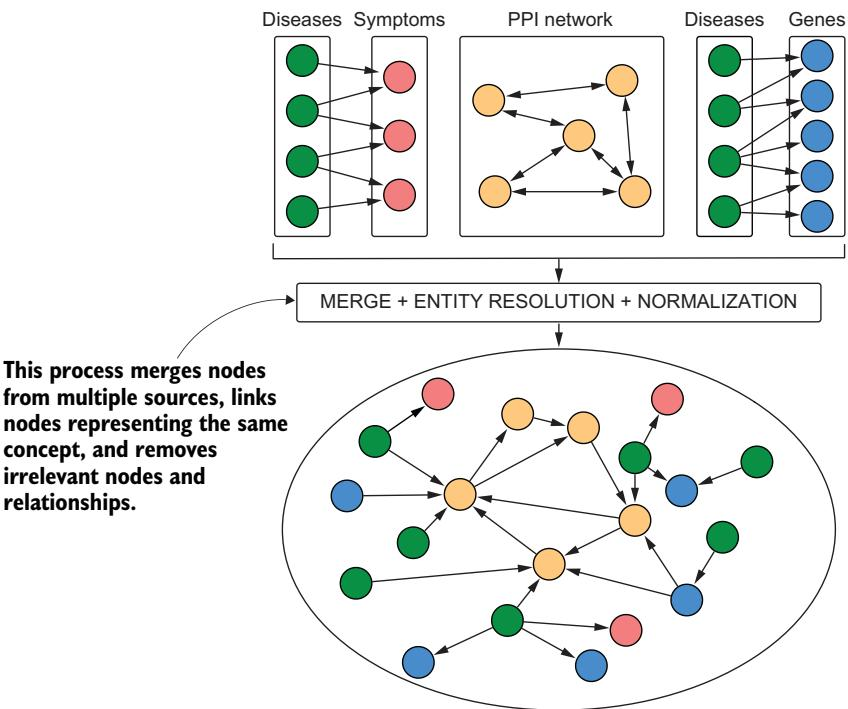

*그림 4.3 — Yang 등이 여러 이질적 소스를 병합해 하나의 통합적 KG 를 만든 방식. 서로 다른 데이터베이스의 질병 식별자를 **UMLS** 코드로 매핑해 용어를 통일했다. 3장에서 온톨로지를 기준 어휘로 쓴 것과 같은 전략이다.*

이 절에서 다룰 사례는 **단백질–단백질 상호작용(PPI)** 네트워크와 단백질–질병 연관성으로 **질병 경로** 를 계산으로 발견하는 것이다. 개별 질병 단백질을 따로 떼어 이해하려 해서는 대부분의 인간 질병을 설명할 수 없기 때문에, 지식 그래프가 핵심 역할을 하는 사례가 된다.

---
## 실행 환경 — 4장은 Neo4j Enterprise 가 필요하다

3장과 다르다. **우회가 불가능하다.** Enterprise 전용 기능이 파이프라인의 시작점에 있다.

| 리스팅 | 요구 기능 | Community |
| --- | --- | --- |
| 4.1 제약조건 | `IS NODE KEY` | ❌ Enterprise 전용 |
| 4.6 `ppi` DB | `CREATE DATABASE ... seedUri` | ❌ 멀티DB + URI 시드 |
| 4.16 `hetionet` DB | 동일 | ❌ |
| 4.20 `ckg` DB | 동일 | ❌ |

Enterprise 는 **평가(evaluation) 목적으로 무료** 다. 상용 계약이 없으면 `NEO4J_ACCEPT_LICENSE_AGREEMENT=eval` 로 평가 계약에 동의한다. 조건은 <https://neo4j.com/terms/enterprise_us/> 에 있고, 통상 비상용·비프로덕션 용도로 제한되므로 **직접 읽고 판단해 동의** 해야 한다.

```bash
docker run -d --name kglm-neo4j-ee \
  -e NEO4J_ACCEPT_LICENSE_AGREEMENT=eval \
  -e NEO4J_AUTH=neo4j/password \
  -e 'NEO4J_PLUGINS=["graph-data-science","apoc"]' \
  -e NEO4J_dbms_databases_seed__from__uri__providers=URLConnectionSeedProvider \
  -e NEO4J_dbms_security_procedures_unrestricted='gds.*,apoc.*' \
  -e NEO4J_dbms_security_procedures_allowlist='gds.*,apoc.*' \
  -e NEO4J_server_memory_heap_max__size=2G \
  -p 127.0.0.1:7474:7474 -p 127.0.0.1:7687:7687 \
  -v kglm-neo4j-ee-data:/data neo4j:5.26-enterprise
```

`seed_from_uri_providers` 는 리스팅 주석이 요구하는 `neo4j.conf` 항목을 환경변수로 준 것이다. 이게 없으면 4.6 이 실패한다.

> **⚠️ `n10s` 는 Enterprise 와 충돌한다.** 플러그인을 하나씩 시험해 확인했다. `apoc`·`gds`·둘의 조합은 정상 기동하지만 `n10s` 를 넣으면 `NoSuchMethodError: JsonProperty.isRequired()` 로 죽는다 (Jackson 버전 충돌). 그래서 위 명령에 `n10s` 가 없다.
>
> 결과적으로 **3장(n10s 필요)과 4장(Enterprise 필요)은 같은 컨테이너에서 돌릴 수 없다.** 3장 작업으로 돌아갈 때는 Community 컨테이너로 전환한다.
>
> ```bash
> docker stop kglm-neo4j-ee && docker start kglm-neo4j     # 3장용 Community 로
> docker stop kglm-neo4j && docker start kglm-neo4j-ee     # 4장용 Enterprise 로
> ```

### 데이터베이스 세 개 — `ckg` 는 선택 사항

| DB | 시드 용량 | 생성 시간 | 노드 | 관계 | 필수 |
| --- | --- | --- | --- | --- | --- |
| `ppi` | 7 MB | 5초 | 23,073 | 363,711 | ✅ 4.2 절 |
| `hetionet` | 69 MB | 8초 | 47,031 | 2,250,197 | ✅ 4.3 절 |
| `ckg` | **5.1 GB** | **약 5분** | 18,606,441 | 205,971,182 | ⬜ 4.4 절만 |

`ckg` 를 쓰는 리스팅은 4.20(생성)·4.21(질의) **둘뿐** 이다. 5.1GB 가 부담이면 건너뛰어도 장의 흐름에 지장이 없다. 이 노트북은 아래 `RUN_CKG` 플래그로 제어하고, 건너뛸 경우 실측 결과를 마크다운으로 보존해 무엇이 나오는지 알 수 있게 했다.

In [1]:
"""환경 점검 — 이 셀이 통과하면 4.2·4.3 절을 모두 돌릴 수 있다."""
from pathlib import Path

from studykit import config, cypher

STUDY = config.load()      # 위로 올라가며 study.toml 을 찾는다
HERE = Path.cwd()          # 주피터는 노트북 폴더를 cwd 로 둔다

RUN_CKG = False            # True 로 바꾸면 4.4 절의 5.1GB ckg 도 만든다

assert (HERE / "listings").is_dir(), f"리스팅 폴더가 없다. cwd 확인: {HERE}"

print("교재        :", STUDY.title)
print("리스팅 오프셋:", STUDY.listing_offsets.get("ch04"), "(0 = 책 번호와 파일 번호가 같다)")

with cypher.driver() as drv, drv.session(database="system") as s:
    info = s.run("CALL dbms.components() YIELD versions, edition "
                 "RETURN versions[0] AS version, edition").single()
    print(f"Neo4j       : {info['version']} ({info['edition']} edition)")
    if info["edition"] != "enterprise":
        raise RuntimeError(
            "4장은 Enterprise 가 필요하다. CREATE DATABASE ... seedUri 와 IS NODE KEY 가\n"
            "  Community 에 없다. 위 docker run 명령으로 Enterprise 컨테이너를 띄워라."
        )
    existing = {r["name"] for r in s.run("SHOW DATABASES YIELD name RETURN DISTINCT name")}
    print("데이터베이스 :", sorted(existing))

with cypher.driver() as drv, drv.session(database="neo4j") as s:
    plugins = s.run("SHOW PROCEDURES YIELD name "
                    "WHERE name STARTS WITH 'gds' OR name STARTS WITH 'apoc' "
                    "RETURN split(name,'.')[0] AS ns, count(*) AS n ORDER BY ns").data()
    print("플러그인     :", {p["ns"]: p["n"] for p in plugins})
    if not any(p["ns"] == "gds" for p in plugins):
        raise RuntimeError("GDS 가 없다. 4.8~4.10 의 WCC·Louvain 을 돌릴 수 없다.")

print("\n준비 완료.")

교재        : Knowledge Graphs and LLMs in Action
리스팅 오프셋: 0 (0 = 책 번호와 파일 번호가 같다)
Neo4j       : 5.26.28 (enterprise edition)
데이터베이스 : ['ckg', 'hetionet', 'neo4j', 'ppi', 'system']
플러그인     : {'apoc': 190, 'gds': 423}

준비 완료.


In [2]:
"""리스팅 접근 헬퍼.

리스팅 번호 대응은 study.toml 의 [mapping.listings.ch04] 가 정본이다. 단일 오프셋으로
표현할 수 없기 때문이다 — 최종 교재는 4.20 에 코드 없는 LLM 프롬프트를 끼워넣어서
그 뒤 번호가 한 칸씩 밀린다.

  책 4.19 = 파일 4.19          (오프셋 0)
  책 4.20 = 해설판 본문         (코드 파일 없음)
  책 4.21 = 파일 4.20          (오프셋 -1)
  책 4.22 = 파일 4.21          (오프셋 -1)
  책 4.23 = 해설판 본문         (코드 파일 없음)

리스팅마다 실행할 데이터베이스도 다르므로(ppi / hetionet / ckg) db 를 명시한다.
"""
import time

# 해설판 본문에서 가져온 리스팅. 저장소에 코드 파일이 없는 것들이다.
# 원문은 아래 4.3.2 · 4.4.1 절 마크다운 셀에 그대로 실어 두었다.
EXPLAINER_ONLY = {"4.20", "4.23"}


def source_of(book_no: str) -> str:
    """책 리스팅 번호로 원문을 가져온다. study.toml 의 대응표를 따른다."""
    kind, value = STUDY.resolve_listing("ch04", book_no)
    if kind != "repo":
        raise KeyError(
            f"책 {book_no} 은 저장소에 코드 파일이 없다 (source={kind}). "
            f"해설판 본문을 실은 마크다운 셀을 보라."
        )
    return cypher.read(value, HERE / "listings").strip()


def show(book_no: str) -> None:
    kind, value = STUDY.resolve_listing("ch04", book_no)
    origin = f"파일 {value}" if kind == "repo" else "해설판 본문"
    print(f"── 책 Listing {book_no}  ({origin}) ──")
    print(source_of(book_no) if kind == "repo" else "(아래 마크다운 셀에 원문을 실었다)")


def statements(book_no: str) -> list:
    """주석만으로 된 조각은 버린다. 4.6·4.16·4.21 은 앞부분이 neo4j.conf 안내 주석이다."""
    out = []
    for chunk in source_of(book_no).split(";"):
        lines = [l for l in chunk.strip().splitlines() if l.strip()]
        if lines and not all(l.strip().startswith("#") for l in lines):
            out.append("\n".join(l for l in lines if not l.strip().startswith("#")).strip())
    return out


def run(book_no: str, db: str, limit: int = 5, **params):
    """책 리스팅을 지정한 데이터베이스에서 실행한다."""
    started = time.time()
    rows = []
    with cypher.driver() as drv, drv.session(database=db) as s:
        for statement in statements(book_no):
            rows = [r.data() for r in s.run(statement, **params)]
    print(f"책 {book_no} [{db}]: {time.time() - started:.1f}초, {len(rows)}행")
    for r in rows[:limit]:
        print("   ", {k: str(v)[:58] for k, v in r.items()})
    return rows


def db_stats(db: str) -> dict:
    with cypher.driver() as drv, drv.session(database=db) as s:
        return {
            "nodes": s.run("MATCH (n) RETURN count(n) AS n").single()["n"],
            "rels": s.run("MATCH ()-[r]->() RETURN count(r) AS n").single()["n"],
        }


# 책 리스팅 -> 저장소 파일 대조표 (study.toml 이 정본)
print(f"{'책':<7}{'출처':<12}대상")
for minor in range(1, 24):
    book_no = f"4.{minor}"
    kind, value = STUDY.resolve_listing("ch04", book_no)
    if kind == "repo":
        try:
            name = cypher.find(value, HERE / "listings").name
        except FileNotFoundError:
            continue
        print(f"{book_no:<7}{'파일':<12}{name}")
    else:
        print(f"{book_no:<7}{'해설판':<12}(코드 파일 없음 — 프롬프트 리스팅)")


책      출처          대상
4.1    파일          4.1 Create the constraints
4.2    파일          4.2 Import PPI Network
4.3    파일          4.3 Import pathways
4.4    파일          4.4 Import disease classes
4.5    파일          4.5 Import gene info
4.6    파일          4.6 Create the PPI database from a neo4j backup
4.7    파일          4.7 Creating a temporal label to mark the proteins in the PPI Network
4.8    파일          4.8 Create the graph projection in memory
4.9    파일          4.9 Run WCC on the PPI Network
4.10   파일          4.10 Run Louvain on the PPI Network
4.11   파일          4.11 Inspect the top 10 communities’ content
4.12   파일          4.12 Extracting disease pathway from the knowledge graph
4.16   파일          4.16 Create the Het.io database
4.17   파일          4.17 GO Process enrichment for celiac disease
4.18   파일          4.18 Tissue-specific interactomics. GO Process enrichment for celiac disease
4.19   파일          4.19 Paths behind the DWPC for positive regulation of glycoprotein biosy

---
### 4.2.1 PPI 와 단백질–질병 네트워크로 KG 만들기

목표는 **이미 알려진 경로에서 출발해 새로운 질병 경로를 발견** 하는 것이다.

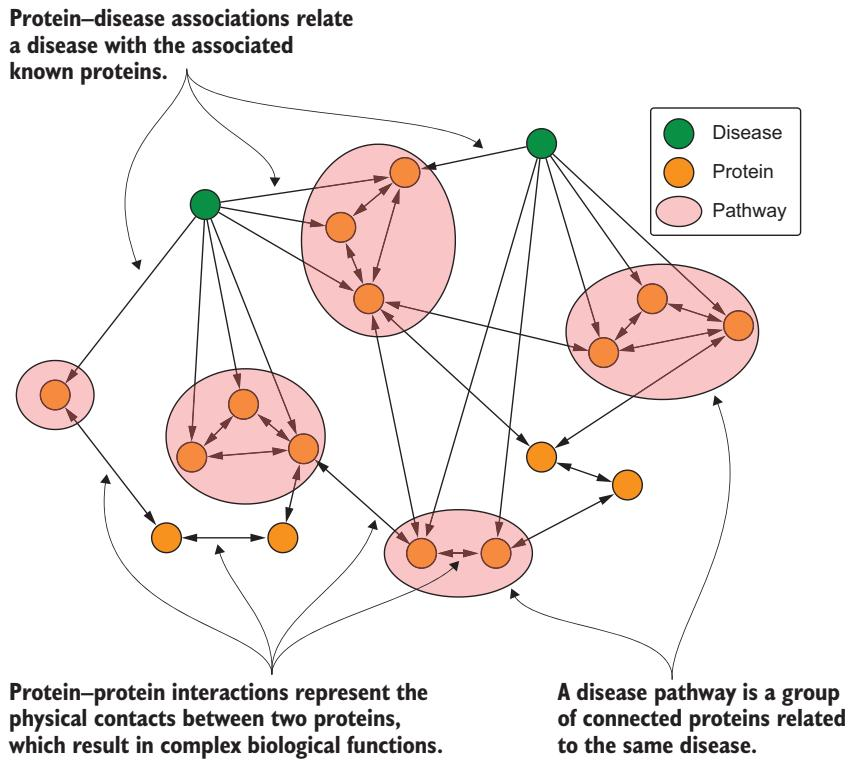

*그림 4.4 — 질병 경로(disease pathway)는 그 질병과 연관된 단백질 집합으로 정의되는 PPI 네트워크의 **부분 그래프** 다. 이 정의가 4.2.3 절 지표 세 개의 출발점이 된다.*

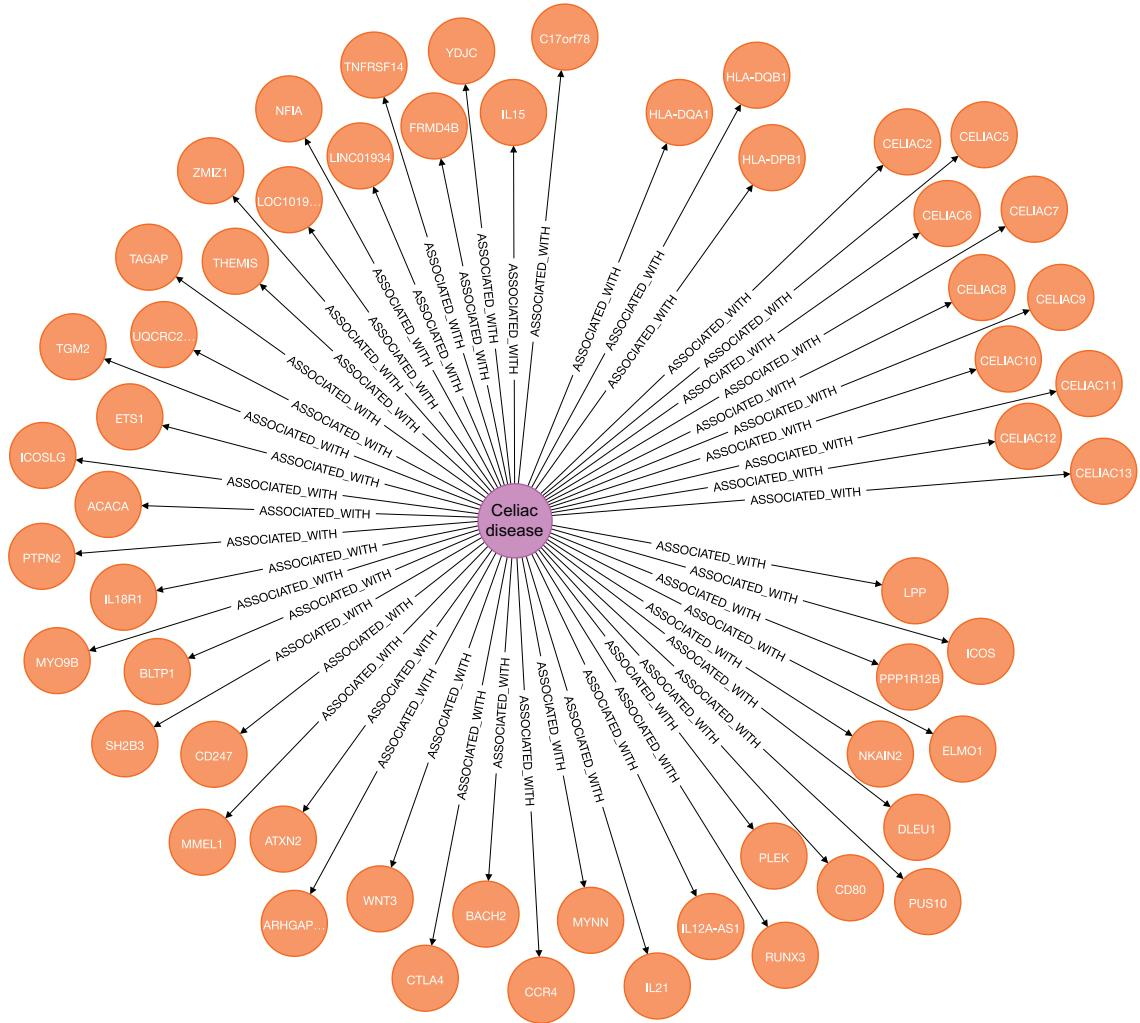

*그림 4.5 — Agrawal 이 구축한 KG 의 작은 일부. 셀리악병에서 출발해 연관 유전자들을 찾은 모습. 셀리악병은 4.3 절에서도 계속 등장한다.*

만들어지는 그래프는 두 부분으로 이루어진다.

- **단일 분할 그래프(monopartite)** — 한 종류의 노드끼리 연결된 PPI 네트워크 (`Protein`—`INTERACTS_WITH`—`Protein`)

- **이분 그래프(bipartite)** — 두 종류의 노드가 연결된 질병–단백질 연관 네트워크 (`Disease`—`ASSOCIATED_WITH`—`Protein`)

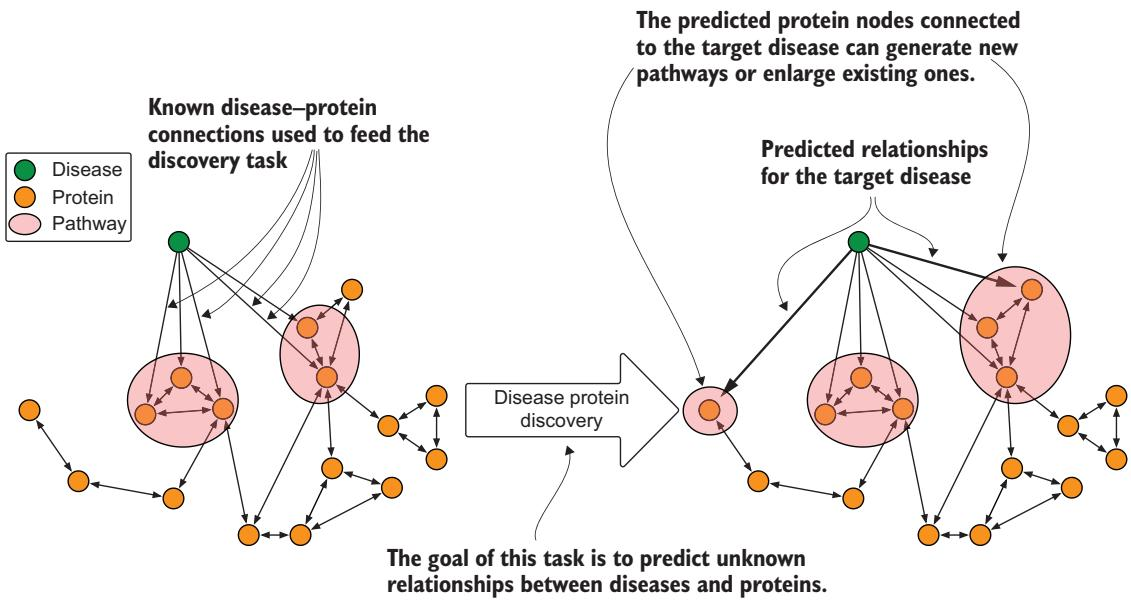

*그림 4.6 — 질병과 관련된 단백질을 찾아내는 발견 과정. 이미 알려진 경로 집합이 입력이고, 지능형 자문 시스템이 연관 가능성 있는 단백질과 경로를 예측해 보고한다.*

### 소스 데이터와 리스팅 4.1\~4.5

| 리스팅 | 소스 | 담는 것 |
| --- | --- | --- |
| 4.1 | — | `Protein`·`Disease` 노드 키 제약 |
| 4.2 | SNAP `bio-pathways-network.csv` | 인간 단백질 21,559개 사이 상호작용 342,354건 |
| 4.3 | SNAP `bio-pathways-associations.csv` | DisGeNET 유래 단백질–질병 연관 21,000+건, 519개 질병 |
| 4.4 | SNAP `bio-pathways-diseaseclasses.csv` | Disease Ontology 2계층 10개 범주 (암 68, 신경계 44, 심혈관 33, 면역 21) |
| 4.5 | NIH `gene_info` | 코드뿐인 단백질에 사람이 읽을 심볼·설명 부여 |

> **4.1\~4.5 는 이 노트북에서 실행하지 않는다.** 세 가지 이유다. 첫째 `LOAD CSV FROM 'file:///PPI/...'` 는 CSV 를 Neo4j 컨테이너의 import 디렉터리에 미리 넣어야 한다. 둘째 그 CSV 원본이 교재 저장소에 없고 Readme 도 출처를 밝히지 않는다. 셋째 `IS NODE KEY` 는 Enterprise 전용이다.
>
> 해설판이 바로 이 상황을 위해 **4.6 의 백업 시드 경로** 를 제공한다. "만약 여기까지 직접 따라 하지 않았더라도 걱정 없습니다." 아래 셀이 그 경로를 쓴다.

In [3]:
"""책 4.1~4.5 원문 확인 — 실행하지 않고 무엇을 하는 코드인지만 본다.

4.2 는 CSV 각 줄에서 두 단백질을 MERGE 하고 INTERACTS_WITH 로 잇는다.
IN TRANSACTIONS OF 100 ROWS 는 100줄씩 끊어 커밋해 메모리 부담을 줄이는 관용구다.
4.3 은 쉼표로 이어진 유전자 ID 목록을 split + UNWIND 로 펼쳐 관계를 만든다.
4.5 는 MATCH 로 기존 노드를 찾아 name·description 만 덧붙인다 (새 노드를 만들지 않는다).
"""
for book_no in ("4.1", "4.2", "4.5"):
    show(book_no)
    print()

── 책 Listing 4.1  (파일 4.1) ──
CREATE CONSTRAINT protein_key IF NOT EXISTS FOR (n:Protein) REQUIRE (n.id) IS NODE KEY;
CREATE CONSTRAINT disease_key IF NOT EXISTS FOR (n:Disease) REQUIRE (n.id) IS NODE KEY;

── 책 Listing 4.2  (파일 4.2) ──
:auto LOAD CSV FROM 'file:///PPI/bio-pathways-network.csv' AS line
CALL {
    WITH line
    MERGE (f:Protein {id: trim(line[0])})
    MERGE (s:Protein {id: trim(line[1])})
    MERGE (f)-[:INTERACTS_WITH]->(s)
} IN TRANSACTIONS OF 100 ROWS

── 책 Listing 4.5  (파일 4.5) ──
:auto LOAD CSV WITH HEADERS FROM 'file:///PPI/gene_info' AS line FIELDTERMINATOR '\t'
CALL {
    WITH line
    WITH trim(line["GeneID"]) AS proteinId, trim(line["Symbol"]) AS symbol,
    trim(line["description"]) AS description
    WITH proteinId, symbol, description
    MATCH (p:Protein {id:proteinId})
    SET p.name = symbol, p.description = description
} IN TRANSACTIONS OF 100 ROWS



### 리스팅 4.6 — 백업 시드로 `ppi` 데이터베이스 만들기

`CREATE DATABASE ... OPTIONS { existingData: "use", seedUri: ... }` 는 원격 백업 파일을 끌어와 데이터베이스를 만든다. Enterprise 전용이고, 컨테이너에 `dbms.databases.seed_from_uri_providers=URLConnectionSeedProvider` 설정이 있어야 한다.

시드 파일은 7MB 이고 실측 **5초** 에 온라인이 된다. 4.1\~4.5 를 직접 돌려 만든 것과 같은 그래프다.

In [4]:
"""책 4.6 — 백업 시드로 ppi 데이터베이스 생성.

CREATE DATABASE 는 비동기다. 명령이 돌아와도 아직 starting 상태일 수 있으므로
online 이 될 때까지 기다려야 한다. 5.4.0 처럼 오래된 백업은 현재 버전으로
마이그레이션하느라 더 오래 걸린다 (4.20 의 ckg 가 그렇다).
"""
def wait_online(db: str, timeout: int = 600) -> float | None:
    started = time.time()
    while time.time() - started < timeout:
        with cypher.driver() as drv, drv.session(database="system") as s:
            rows = s.run(f"SHOW DATABASE {db} YIELD currentStatus "
                         f"RETURN currentStatus AS st").data()
        if rows and rows[0]["st"] == "online":
            return time.time() - started
        time.sleep(2)
    return None


show("4.6")

with cypher.driver() as drv, drv.session(database="system") as s:
    already = s.run("SHOW DATABASES YIELD name RETURN collect(DISTINCT name) AS n").single()["n"]

if "ppi" in already:
    print("\n이미 존재 — 건너뜀")
else:
    print("\n생성 중...")
    for statement in statements("4.6"):
        with cypher.driver() as drv, drv.session(database="system") as s:
            s.run(statement).consume()
    elapsed = wait_online("ppi")
    print(f"online ({elapsed:.1f}초)" if elapsed else "타임아웃")

print("ppi 규모:", {k: f"{v:,}" for k, v in db_stats("ppi").items()})

── 책 Listing 4.6  (파일 4.6) ──
# Add the following line to the neo4j.conf file
# dbms.databases.seed_from_uri_providers=URLConnectionSeedProvider
# then run the following command

CREATE DATABASE ppi OPTIONS { existingData: "use", seedUri: "https://downloads.graphaware.com/neo4j-db-seeds/ppi-5.26.4-2025-03-22T08-30-33.backup"}

이미 존재 — 건너뜀
ppi 규모: {'nodes': '23,073', 'rels': '363,711'}


In [5]:
"""실습 4-A — 해설판 4.2.1 의 연습문제 세 개.

(1) 4.2 직후의 단백질 수와 연결 수를 확인하라. 다음 단계가 새 단백질을 추가하므로
    반드시 그 전에 봐야 한다.
(2) 4.3 이후 단백질 수가 달라진다. 새로 생긴 단백질을 찾아라. 힌트: NOT EXISTS
(3) 질병의 범주별 수치와, 범주가 없는 질병 목록을 확인하라.

백업 시드로 만든 그래프는 4.2~4.5 가 모두 끝난 상태다. 그래서 (1)(2)를 시간 순서로
재현할 수는 없다. 대신 "그 차이가 그래프에 남긴 흔적"을 찾는 방식으로 푼다.
"""
QUERIES = {
    "(1) 전체 단백질·상호작용 수": """
        MATCH (p:Protein) WITH count(p) AS proteins
        MATCH ()-[r:INTERACTS_WITH]->() RETURN proteins, count(r) AS interactions""",
    "(2) PPI 상호작용이 없는 단백질 = 4.3 이 새로 만든 것": """
        MATCH (p:Protein)
        WHERE NOT EXISTS { (p)-[:INTERACTS_WITH]-() }
        RETURN count(p) AS only_from_associations""",
    "(2b) 그중 표본": """
        MATCH (p:Protein)
        WHERE NOT EXISTS { (p)-[:INTERACTS_WITH]-() }
        MATCH (d:Disease)-[:ASSOCIATED_WITH]->(p)
        RETURN p.id AS protein_id, p.name AS name, collect(d.name)[..2] AS diseases
        LIMIT 5""",
    "(3) 질병 범주별 수": """
        MATCH (d:Disease)
        RETURN coalesce(d.class, '(범주 없음)') AS class, count(*) AS diseases
        ORDER BY diseases DESC""",
}

with cypher.driver() as drv, drv.session(database="ppi") as s:
    for label, query in QUERIES.items():
        print(f"\n── {label}")
        for row in s.run(query).data():
            print("   ", {k: str(v)[:56] for k, v in row.items()})


── (1) 전체 단백질·상호작용 수


    {'proteins': '22554', 'interactions': '342354'}

── (2) PPI 상호작용이 없는 단백질 = 4.3 이 새로 만든 것
    {'only_from_associations': '995'}

── (2b) 그중 표본
    {'protein_id': '57419', 'name': 'SLC24A3', 'diseases': "['Salivary Gland Neoplasms', 'Adenoid Cystic Carcinoma']"}
    {'protein_id': '65245', 'name': 'PSORS7', 'diseases': "['Psoriasis']"}
    {'protein_id': '140454', 'name': 'PSORS8', 'diseases': "['Psoriasis']"}
    {'protein_id': '503613', 'name': 'PSORS10', 'diseases': "['Psoriasis']"}
    {'protein_id': '10547', 'name': 'PSORS4', 'diseases': "['Psoriasis']"}

── (3) 질병 범주별 수
    {'class': '(범주 없음)', 'diseases': '219'}
    {'class': 'cancer', 'diseases': '68'}
    {'class': 'nervous system disease', 'diseases': '44'}
    {'class': 'cardiovascular system disease', 'diseases': '33'}
    {'class': 'immune system disease', 'diseases': '21'}
    {'class': 'gastrointestinal system disease', 'diseases': '16'}
    {'class': 'musculoskeletal system disease', 'diseases': '16'}
    {'class': 'i

---
### 4.2.2 고수준 분석 — 전체 구조 살펴보기

먼저 PPI 네트워크 **전체** 가 어떻게 구성돼 있는지 본다. 쓰는 알고리즘은 **약하게 연결된 컴포넌트(WCC)** — 그래프 안에서 서로 끊긴 부분 그래프를 찾는다 — 와 **Louvain** — 모듈성을 최대화하는 커뮤니티를 찾는다 — 이고, Neo4j **GDS** 라이브러리로 실행한다.

순서에 이유가 있다.

1. **4.7** `INTERACTS_WITH` 로 연결된 단백질에만 `PPIProtein` 레이블을 붙인다. 4.3 이 만든 "연관만 있고 상호작용은 없는" 단백질을 분석에서 빼기 위한 임시 표시다
2. **4.8** 그 레이블로 인메모리 그래프를 투영한다. GDS 는 디스크 그래프를 직접 읽지 않고 투영본에서 계산한다. `orientation: 'UNDIRECTED'` 는 상호작용이 방향 없는 관계임을 반영한다
3. **4.9** WCC 로 끊긴 덩어리를 센다
4. **4.10** Louvain 으로 커뮤니티를 나눈다
5. **4.11** 큰 커뮤니티의 내용을 들여다본다

In [6]:
"""책 4.7~4.11 — GDS 커뮤니티 탐지 파이프라인.

투영본(ppi-graph)이 이미 있으면 4.8 이 실패하므로 먼저 지운다. GDS 투영은
데이터베이스가 아니라 세션 메모리에 살아 있어 재실행 시 충돌한다.
"""
for book_no in ("4.7", "4.8", "4.9", "4.10", "4.11"):
    show(book_no)
    print()

with cypher.driver() as drv, drv.session(database="ppi") as s:
    s.run("CALL gds.graph.drop('ppi-graph', false)").consume()   # 없어도 에러 안 남

run("4.7", "ppi", limit=0)
run("4.8", "ppi", limit=1)

wcc = run("4.9", "ppi", limit=1)
print(f"   -> 연결 컴포넌트 {wcc[0]['componentCount']}개")

louvain = run("4.10", "ppi", limit=1)
print(f"   -> 커뮤니티 {louvain[0]['communityCount']}개, "
      f"모듈성 {louvain[0]['modularity']:.4f}")

top = run("4.11", "ppi", limit=0)
print("\n상위 커뮤니티 (멤버 수 · 대표 유전자):")
for row in top[:5]:
    members = row["keyMembers"][:6]
    print(f"   {row['members']:>5}명  {', '.join(m for m in members if m)}")

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated field from a procedure. ('schema' returned by 'gds.graph.drop' is deprecated.)} {position: line: 1, column: 1, offset: 0} for query: "CALL gds.graph.drop('ppi-graph', false)"


── 책 Listing 4.7  (파일 4.7) ──
MATCH (p:Protein)-[:INTERACTS_WITH]-()
SET p:PPIProtein

── 책 Listing 4.8  (파일 4.8) ──
call gds.graph.project(
    'ppi-graph',
    'PPIProtein',
    {
        INTERACTS_WITH: {
            orientation: 'UNDIRECTED'
        }
    }
)

── 책 Listing 4.9  (파일 4.9) ──
CALL gds.wcc.write('ppi-graph', { writeProperty: 'componentId' })
YIELD nodePropertiesWritten, componentCount, componentDistribution;

── 책 Listing 4.10  (파일 4.10) ──
CALL gds.louvain.write('ppi-graph',
{ writeProperty: 'componentLouvainId' })
YIELD communityCount, modularity, modularities, communityDistribution

── 책 Listing 4.11  (파일 4.11) ──
MATCH (p:PPIProtein)
WITH p.componentLouvainId as communityId, count(p) as members
ORDER BY members desc
LIMIT 10
MATCH (p:PPIProtein)-[:INTERACTS_WITH]-(o)
WHERE p.componentLouvainId = communityId
WITH communityId, members, p.name as name, count(o) as connections
ORDER BY connections DESC
RETURN communityId, members, collect(name)[..20] as keyMembers



책 4.7 [ppi]: 0.2초, 0행


책 4.8 [ppi]: 0.1초, 1행
    {'nodeProjection': "{'PPIProtein': {'properties': {}, 'label': 'PPIProtein'}}", 'relationshipProjection': "{'INTERACTS_WITH': {'orientation': 'UNDIRECTED', 'aggregat", 'graphName': 'ppi-graph', 'nodeCount': '21559', 'relationshipCount': '684708', 'projectMillis': '40'}
책 4.9 [ppi]: 0.0초, 1행
    {'nodePropertiesWritten': '21559', 'componentCount': '27', 'componentDistribution': "{'p1': 1, 'max': 21521, 'p5': 1, 'p90': 3, 'p50': 1, 'p95'"}
   -> 연결 컴포넌트 27개


책 4.10 [ppi]: 14.8초, 1행
    {'communityCount': '42', 'modularity': '0.39408353566939225', 'modularities': '[0.3666030491251097, 0.39315103524857153, 0.39408353566939', 'communityDistribution': "{'p1': 1, 'max': 3786, 'p5': 1, 'p90': 2349, 'p50': 2, 'p9"}
   -> 커뮤니티 42개, 모듈성 0.3941
책 4.11 [ppi]: 0.2초, 10행

상위 커뮤니티 (멤버 수 · 대표 유전자):
    3786명  APP, ELAVL1, MOV10, NXF1, FBXO6, VCP
    3629명  NTRK1, GRB2, EGFR, YWHAZ, YWHAG, CALM1
    2349명  UBC, HSPA8, TRAF6, HSPA5, BAG3, VHL
    1379명  XPO1, MED4, BTRC, PPP2R1A, DYNLL1, CEP128
    1448명  CUL3, MCM2, COPS5, FN1, CUL1, RNF2


---
### 4.2.3 도메인 특화 분석 — 질병 경로를 자로 재다

앞은 네트워크 **전체** 를 봤다. 이제 **부분 그래프**, 즉 질병 경로를 잰다.

PPI 네트워크를 $G = (V, E)$ 라 하면 (노드 $V$ = 단백질, 엣지 $E$ = 상호작용), 질병 $d$ 의 질병 경로는 무방향 부분 그래프 $H_d = (V_d, E_d)$ 다.

$$E_{d} = \{ (u, v) \mid (u, v) \in E \text{ and } u, v \in V_{d} \}$$

즉 **양쪽 끝이 모두 질병 단백질인 상호작용만** 골라낸 것이다. 지표를 계산할 때는 이 부분 그래프가 나머지와 어떻게 이어져 있는지도 봐야 하므로 **경로 경계** $B_d$ 를 함께 정의한다.

$$B_{d} = \{ (u, v) \mid (u, v) \in E \text{ and } u \in V_{d} \text{ and } v \in V \setminus V_{d} \}$$

한쪽 끝은 질병 단백질, 다른 쪽은 아닌 **안과 밖을 잇는 엣지** 집합이다. 이 둘로 지표 세 개를 만든다.

| 지표 | 수식 | 읽는 법 |
| --- | --- | --- |
| **가장 큰 경로 컴포넌트** | $\dfrac{\lvert \text{nodes}(\text{largestCC}(H_d)) \rvert}{\lvert V_d \rvert}$ | 질병 단백질이 한 덩어리로 뭉쳤나. 1 에 가까우면 하나로 뭉침 |
| **밀도** | $\dfrac{2\lvert E_d \rvert}{\lvert V_d \rvert (\lvert V_d \rvert - 1)}$ | 경로 **안** 이 얼마나 촘촘한가. [0,1] |
| **전도도** | $\dfrac{\lvert B_d \rvert}{\lvert B_d \rvert + 2\lvert E_d \rvert}$ | 경로가 나머지와 얼마나 **분리** 됐나. 낮을수록 독립적 커뮤니티 |

구현은 `analysis/multiomic_analysis.py` 에 있고 `networkx` 를 쓴다. 아래 셀이 셀리악병에 대해 세 지표를 직접 계산한다.

In [7]:
"""책 4.12~4.15 — 질병 경로 지표 세 개를 셀리악병에 대해 계산한다.

4.12 로 질병 경로 부분 그래프를 뽑고, 4.13~4.15 의 수식을 그대로 옮겼다.
업스트림 analysis/multiomic_analysis.py 는 networkx 로 같은 일을 한다. 여기서는
질병 경로가 작으므로(단백질 수십~수백 개) 파이썬 BFS 로 직접 센다. 의존성이 줄고
"연결 컴포넌트를 센다"는 것이 무슨 뜻인지도 눈에 보인다.

★ 이름 표기가 소스마다 다르다. ppi 는 'Celiac Disease'(Title Case), hetionet 은
  'celiac disease'(lower case) 다. 같은 질병인데 표기가 갈린다. 바로 이것이 4장이
  말하는 "이름과 식별자를 서로 맞춰(reconcile) 짝짓기" 문제의 실물이다.
"""
from collections import deque

show("4.12")

DISEASE = "celiac disease"      # 비교는 toLower() 로 한다

PATHWAY = """
MATCH (d:Disease)-[:ASSOCIATED_WITH]->(p:Protein)
WHERE toLower(d.name) = toLower($name)
WITH d, collect(DISTINCT p) AS proteins
CALL (proteins) {
    // Ed: 양쪽 끝이 모두 질병 단백질인 상호작용
    MATCH (m0)-[:INTERACTS_WITH]-(m1)
    WHERE m0 IN proteins AND m1 IN proteins
    RETURN collect(DISTINCT [elementId(m0), elementId(m1)]) AS inside
}
CALL (proteins) {
    // Bd: 한쪽만 질병 단백질인 상호작용 (경로 경계)
    MATCH (m0)-[r:INTERACTS_WITH]-(m1)
    WHERE m0 IN proteins AND NOT m1 IN proteins
    RETURN count(DISTINCT r) AS bd
}
RETURN d.id AS disease_id, d.name AS disease_name,
       [p IN proteins | elementId(p)] AS node_ids, inside, bd
"""

with cypher.driver() as drv, drv.session(database="ppi") as s:
    row = s.run(PATHWAY, name=DISEASE).single()
if row is None:
    raise RuntimeError(f"ppi 에서 '{DISEASE}' 를 찾지 못했다. 표기를 확인하라.")

print(f"\nppi 의 실제 표기: {row['disease_name']} ({row['disease_id']})")

nodes = set(row["node_ids"])
# 무방향으로 다루므로 양쪽 방향을 모두 넣는다
adjacency = {n: set() for n in nodes}
edges = set()
for a, b in row["inside"]:
    if a in adjacency and b in adjacency:
        adjacency[a].add(b)
        adjacency[b].add(a)
        edges.add(frozenset((a, b)))

vd, ed, bd = len(nodes), len(edges), row["bd"]


def connected_components(adj: dict) -> list[int]:
    """BFS 로 연결 컴포넌트 크기 목록을 구한다 (큰 것부터)."""
    seen, sizes = set(), []
    for start in adj:
        if start in seen:
            continue
        queue, size = deque([start]), 0
        seen.add(start)
        while queue:
            current = queue.popleft()
            size += 1
            for neighbour in adj[current] - seen:
                seen.add(neighbour)
                queue.append(neighbour)
        sizes.append(size)
    return sorted(sizes, reverse=True)


sizes = connected_components(adjacency)
relative_largest = sizes[0] / vd
density = 2.0 * ed / (vd * (vd - 1))
conductance = bd / (bd + 2 * ed)

print(f"\n=== {DISEASE} 질병 경로 지표 ===")
print(f"  |Vd| 질병 단백질          : {vd}")
print(f"  |Ed| 내부 상호작용        : {ed}")
print(f"  |Bd| 경계 상호작용        : {bd:,}")
print(f"  연결 컴포넌트 수          : {len(sizes)}      (책 전체 중앙값 16)")
print(f"  가장 큰 컴포넌트 크기     : {sizes[0]}")
print(f"  가장 큰 컴포넌트 상대크기 : {relative_largest:.3f}   (책 중앙값 0.21)")
print(f"  밀도                      : {density:.4f}  (책 중앙값 0.07 · PPI 전체 0.0015)")
print(f"  전도도                    : {conductance:.4f}  (책 중앙값 0.96)")
print(f"  컴포넌트 크기 분포        : {sizes[:12]}{' ...' if len(sizes) > 12 else ''}")
print("\n해석: 밀도가 낮고 전도도가 높으면 그 질병의 단백질들은 서로 뭉쳐 있기보다")
print("      네트워크 곳곳에 흩어져 다른 단백질들과 뒤섞여 있다는 뜻이다.")


── 책 Listing 4.12  (파일 4.12) ──
MATCH (d:Disease {id:$id})-[:ASSOCIATED_WITH]->(p)
WITH collect(p) as proteins
UNWIND proteins as m0
UNWIND proteins as m1
OPTIONAL MATCH (m0)-[r:INTERACTS_WITH]->(m1)
RETURN DISTINCT m0, r, m1



ppi 의 실제 표기: Celiac Disease (C0007570)

=== celiac disease 질병 경로 지표 ===
  |Vd| 질병 단백질          : 55
  |Ed| 내부 상호작용        : 15
  |Bd| 경계 상호작용        : 1,003
  연결 컴포넌트 수          : 50      (책 전체 중앙값 16)
  가장 큰 컴포넌트 크기     : 3
  가장 큰 컴포넌트 상대크기 : 0.055   (책 중앙값 0.21)
  밀도                      : 0.0101  (책 중앙값 0.07 · PPI 전체 0.0015)
  전도도                    : 0.9710  (책 중앙값 0.96)
  컴포넌트 크기 분포        : [3, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1] ...

해석: 밀도가 낮고 전도도가 높으면 그 질병의 단백질들은 서로 뭉쳐 있기보다
      네트워크 곳곳에 흩어져 다른 단백질들과 뒤섞여 있다는 뜻이다.


### 질병 경로 vs Louvain 클러스터 — 책의 분포와 대조

책은 519개 질병 전체에 대해 세 지표를 계산해 분포를 그렸다. 위 셀은 셀리악병 하나만 쟀으니, 전체 그림은 책의 분포로 본다.

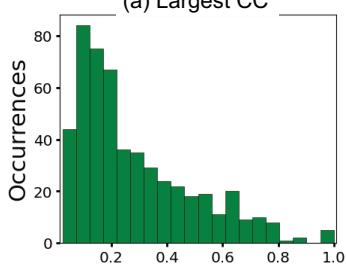

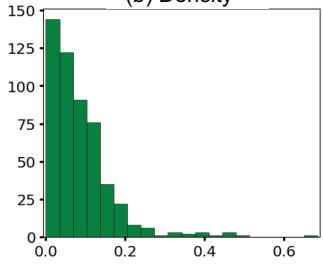

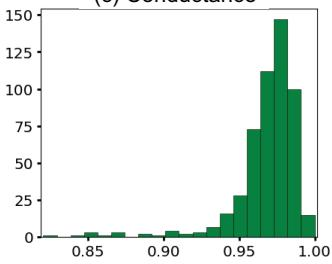

*그림 4.7 — 질병 경로에 대한 세 핵심 측정값의 분포. 질병당 연결 컴포넌트 중앙값 **16개**, 가장 큰 경로 컴포넌트에 든 단백질은 중앙값 **21%** 뿐이다. 밀도 중앙값 **0.07**(PPI 전체는 0.0015), 전도도 중앙값 **0.96**. 즉 한 질병에 관여하는 단백질들은 서로 뭉쳐 있기보다 네트워크 곳곳에 흩어져 다른 단백질과 뒤섞여 있다.*

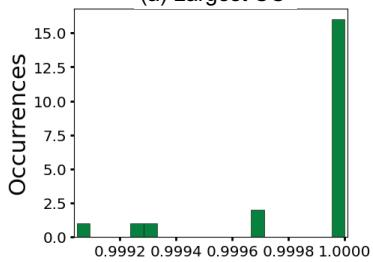

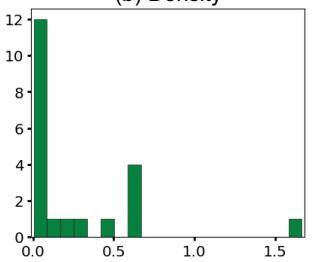

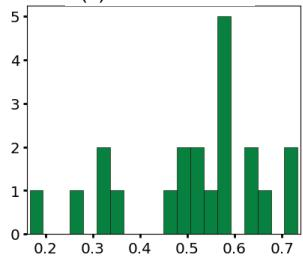

*그림 4.8 — 같은 지표를 Louvain 클러스터에 적용한 분포. 대비가 뚜렷하다. 대부분의 단백질이 하나의 큰 컴포넌트에 자리하고, 전도도가 개선돼 **내부가 외부보다 잘 연결** 된다. Louvain 클러스터는 "안이 촘촘하고 밖과 성긴" 진짜 커뮤니티인 반면, 질병 경로는 그렇지 않다.*

**이 대비가 4.2 절의 결론이다.** 커뮤니티 탐지로 얻은 덩어리와 "한 질병에 관여하는 단백질 집합"은 전혀 다른 대상이다. 그래서 질병 경로를 찾는 데는 군집화가 아니라 다른 접근이 필요하고, 4.3 절이 그 접근(경로 기반 지표)을 가져온다.

---
## 4.3 제약 응용 — 약물 재활용의 지름길

신약 하나를 개발하는 데 약 **14억 달러**, 첫 화합물에서 시장까지 보통 **15년** 이 걸리고 성공 확률은 낮다. **약물 재활용(drug repurposing)** 은 이미 승인된 약물의 기존 정보 — 독성 프로파일, 전임상 모델, 임상시험, 출시 후 감시 — 를 활용해 이 기간·실패율·비용을 줄인다.

기존 추천 시스템 접근(협업 필터링)의 한계는 **그래프에 담긴 약물과 질병에만 한정** 된다는 것이다. 화학 구조·생물학적 과정 같은 지식을 함께 표현해 그래프를 풍부하게 하면 아직 세상에 없는 화합물에 대해서도 예측할 수 있다.

**Hetionet** 이 그 사례다. Himmelstein 등이 29개 공개 자원의 지식을 인코딩해 화합물·질병·유전자·해부구조·경로·생물학적 과정·분자기능·세포구성요소·약리학적 분류·부작용·증상을 연결했다. 이름은 "hetnet"(heterogeneous network)에서 왔다.

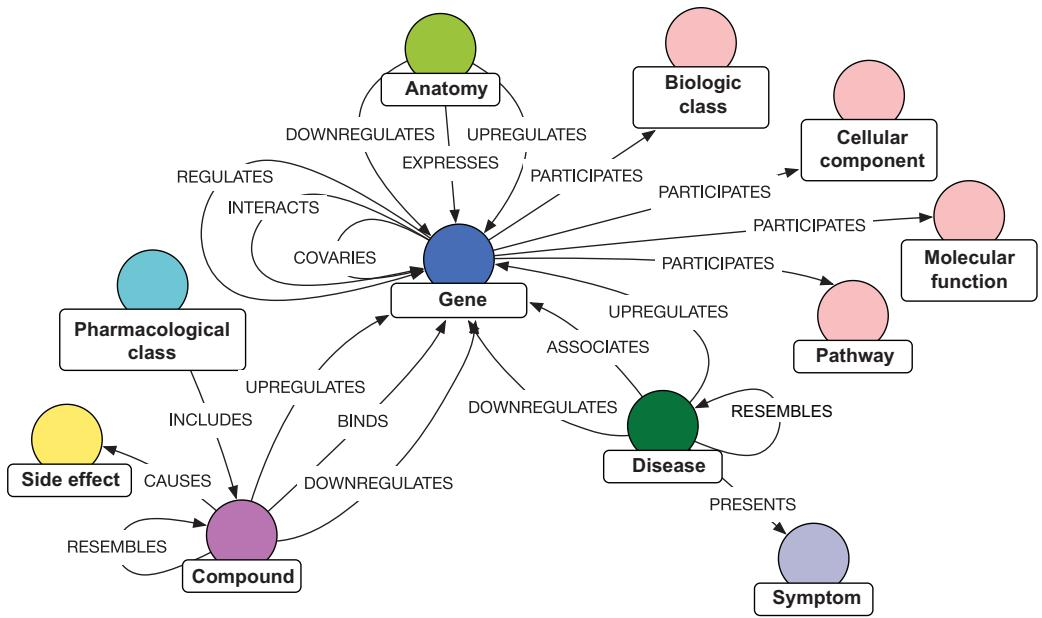

*그림 4.9 — Het.io 지식 그래프 스키마. 노드 11종 47,031개, 관계 24종 2,250,197개. 저분자 화합물 1,552개, 복합 질병 137개를 포함한다. 예컨대 `Compound–binds–Gene` 엣지는 화합물이 유전자가 암호화하는 단백질에 결합함을 뜻하고 11,571개가 있으며, 각각에 참고 문헌이 관계 속성으로 저장돼 있다.*

### 메타경로와 DWPC

**메타경로(metapath)** 는 실제 경로가 아니라 **노드·관계 유형의 시퀀스** 다. "역—지하철—역"이라는 이동 패턴을 말하는 것이지 특정 노선을 가리키는 게 아니다.

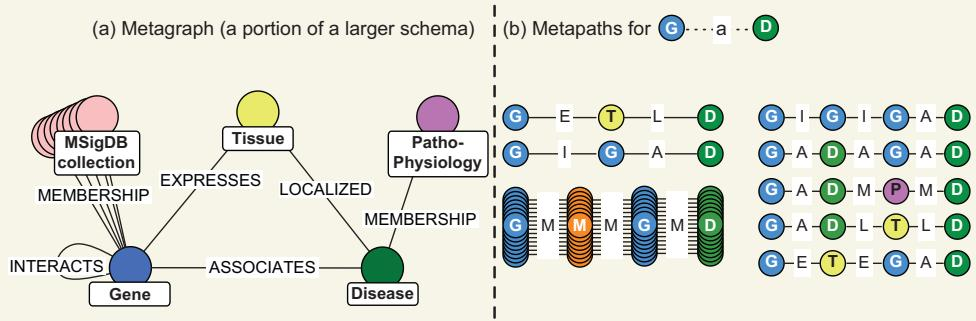

*그림 4.10a — **메타그래프** 는 데이터베이스의 구조(노드 유형·관계 유형)를 묘사한다. 스키마를 "질의"하듯 뒤져 출발 유형과 도착 유형 사이의 연결 패턴을 찾을 수 있다.*

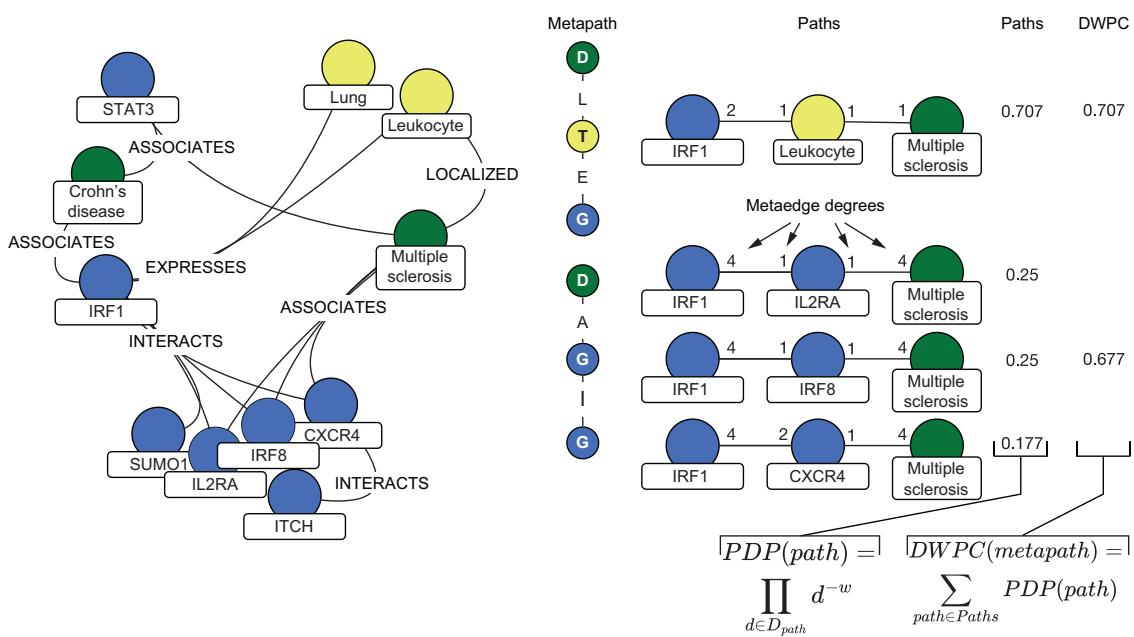

*그림 4.10b — PC(Path Count)와 PDP·DWPC 계산. 유전자 IRF1 과 질병 다발성 경화증 사이 경로들이 메타경로별로 묶여 있다. Tissue 를 중간 노드로 갖는 첫 그룹은 경로가 하나라 PC=1, 다른 유전자를 중간 노드로 갖는 두 번째 그룹은 셋이라 PC=3 이다.*

**PC(Path Count)** 는 경로를 그냥 센다. 각 경로의 값이 1 이므로 **그래프가 얼마나 연결돼 있는지 보정하지 않는다.** 그래서 아무하고나 연결된 인기 노드를 지나는 경로가 과대평가된다.

**DWPC** 는 각 경로에 **경로-차수 곱(Path-Degree Product, PDP)** 을 부여한다.

$$\mathrm{PDP}(\mathrm{path}) = \prod_{d \in D_{\mathrm{path}}} d^{-w}$$

계산 순서는 세 단계다.

1. 경로를 따라 각 메타엣지별 차수를 모두 모은다($D_\mathrm{path}$). **엣지 하나가 차수 두 개를 기여한다** — 그림 4.10 에서 IRF1↔IL2RA 엣지는 4 와 1 을 낸다 (IRF1 은 INTERACTS 나가는 엣지 4개, IL2RA 는 들어오는 엣지 1개)

2. 각 차수를 $-w$ 승 한다. $w \geq 0$ 을 **감쇠 지수(damping exponent)** 라 하고, 클수록 연결이 많은 노드를 지나는 경로를 더 깎는다

3. 모두 곱해 PDP 를 얻는다. 예: $4^{-0.5} \times 2^{-0.5} \times 1^{-0.5} \times 4^{-0.5} \approx 0.177$

$$\mathrm{DWPC}_{m}(s, t) = \sum_{\mathrm{path} \in \mathrm{Paths}_{m}(s,t)} \mathrm{PDP}(\mathrm{path})$$

즉 **특정 메타경로에 속한 모든 경로의 PDP 합** 이다. 이 지표의 핵심은 지식 그래프 분석의 흔한 함정 — "너무 유명한 노드" — 를 자동으로 낮게 취급해 진짜 특이한 연결을 드러낸다는 점이다. 아래 4.3.1 절에서 이 효과를 실측으로 확인한다.

In [8]:
"""책 4.16 — 백업 시드로 hetionet 데이터베이스 생성. 69MB, 실측 8초."""
show("4.16")

with cypher.driver() as drv, drv.session(database="system") as s:
    already = s.run("SHOW DATABASES YIELD name RETURN collect(DISTINCT name) AS n").single()["n"]

if "hetionet" in already:
    print("\n이미 존재 — 건너뜀")
else:
    print("\n생성 중...")
    for statement in statements("4.16"):
        with cypher.driver() as drv, drv.session(database="system") as s:
            s.run(statement).consume()
    elapsed = wait_online("hetionet")
    print(f"online ({elapsed:.1f}초)" if elapsed else "타임아웃")

print("hetionet 규모:", {k: f"{v:,}" for k, v in db_stats("hetionet").items()})

── 책 Listing 4.16  (파일 4.16) ──
# Add the following line to the neo4j.conf file
# dbms.databases.seed_from_uri_providers=URLConnectionSeedProvider
# then run the following command

CREATE DATABASE hetionet OPTIONS { existingData: "use", seedUri: "https://downloads.graphaware.com/neo4j-db-seeds/hetionet-5.26.4-2025-03-22T11-39-51.backup"}

이미 존재 — 건너뜀
hetionet 규모: {'nodes': '47,031', 'rels': '2,250,197'}


In [9]:
"""실습 4-B — 해설판 4.3 의 연습문제.

  "가져온 그래프를 탐색하고, 노드들이 서로 다른 노드 유형에 어떻게 분포하는지
   살펴보세요. 관계에 대해서도 같은 작업을 해 보세요. 다만 관계는 더 복잡할 수
   있으니 조심해야 합니다."

관계가 복잡하다는 경고의 뜻: Hetionet 의 관계 타입 이름에는 메타경로 약어가
박혀 있다(ASSOCIATES_DaG = Disease-associates-Gene). 그래서 타입 수를 세는 것만으로는
스키마를 이해할 수 없고, 어느 노드 유형 쌍을 잇는지 함께 봐야 한다.
"""
with cypher.driver() as drv, drv.session(database="hetionet") as s:
    print("=== 노드 유형별 분포 ===")
    for row in s.run("MATCH (n) UNWIND labels(n) AS label "
                     "RETURN label, count(*) AS n ORDER BY n DESC").data():
        print(f"    {row['label']:<22} {row['n']:>7,}")

    print("\n=== 관계 유형별 분포 (상위 12) ===")
    for row in s.run("MATCH ()-[r]->() RETURN type(r) AS type, count(*) AS n "
                     "ORDER BY n DESC LIMIT 12").data():
        print(f"    {row['type']:<22} {row['n']:>9,}")

    print("\n=== 관계가 잇는 노드 유형 쌍 (약어 해독) ===")
    for row in s.run("""
        MATCH (a)-[r]->(b)
        WITH type(r) AS type, labels(a)[0] AS src, labels(b)[0] AS dst, count(*) AS n
        ORDER BY n DESC LIMIT 8
        RETURN type, src, dst, n""").data():
        print(f"    {row['type']:<22} {row['src']} -> {row['dst']}  ({row['n']:,})")

=== 노드 유형별 분포 ===
    Gene                    20,945
    BiologicalProcess       11,381
    SideEffect               5,734
    MolecularFunction        2,884
    Pathway                  1,822
    Compound                 1,552
    CellularComponent        1,391
    Symptom                    438
    Anatomy                    402
    PharmacologicClass         345
    Disease                    137

=== 관계 유형별 분포 (상위 12) ===


    PARTICIPATES_GpBP        559,504
    EXPRESSES_AeG            526,407
    REGULATES_GrG            265,672
    INTERACTS_GiG            147,164
    CAUSES_CcSE              138,944
    DOWNREGULATES_AdG        102,240
    UPREGULATES_AuG           97,848
    PARTICIPATES_GpMF         97,222
    PARTICIPATES_GpPW         84,372
    PARTICIPATES_GpCC         73,566
    COVARIES_GcG              61,690
    DOWNREGULATES_CdG         21,102

=== 관계가 잇는 노드 유형 쌍 (약어 해독) ===


    PARTICIPATES_GpBP      Gene -> BiologicalProcess  (559,504)
    EXPRESSES_AeG          Anatomy -> Gene  (526,407)
    REGULATES_GrG          Gene -> Gene  (265,672)
    INTERACTS_GiG          Gene -> Gene  (147,164)
    CAUSES_CcSE            Compound -> SideEffect  (138,944)
    DOWNREGULATES_AdG      Anatomy -> Gene  (102,240)
    UPREGULATES_AuG        Anatomy -> Gene  (97,848)
    PARTICIPATES_GpMF      Gene -> MolecularFunction  (97,222)


---
### 4.3.1 Hetionet 심층 분석 — 셀리악병을 파고들다

**셀리악병(celiac disease, CD)** 을 예로 삼는다. 유병률 1:100 으로 흔하고, 만성적이며, 유전적으로 취약한 개인에게서 글루텐 불내성으로 발생하는 면역 매개성 장질환이다. Hetionet 에서 셀리악병과 연관된 유전자는 48개다.

목표는 **셀리악 관련 유전자가 두드러지게 참여하는 유전자 온톨로지(GO) 과정을 찾는 것** 이다. 리스팅 두 개가 정교함의 단계를 보여준다.

| 리스팅 | 메타경로 | 추가 제약 |
| --- | --- | --- |
| **4.17** | `Disease -ASSOCIATES_DaG- Gene -PARTICIPATES_GpBP- BiologicalProcess` | GO 과정 유전자 ≥5, PC ≥2 |
| **4.18** | `Disease -ASSOCIATES_DaG- Gene -INTERACTS_GiG- Gene -PARTICIPATES_GpBP- BiologicalProcess` | GWAS Catalog 유래 연관만 · 병변 조직에서 상향조절된 유전자만 · 5 ≤ 유전자 ≤ 100 |

4.18 이 세 가지를 더 좁힌다. **GWAS 유래 연관** 은 기존 지식에 덜 편향돼 있고, **단백질 상호작용 한 단계 추가** 는 셀리악 인터랙톰의 이웃 유전자를 포착하며, **조직 특이 상향조절** 은 실제 병변에서 일어나는 일로 제한한다.

Cypher 에서 DWPC 를 계산하는 관용구가 두 개 있다.

```cypher
size([(n0)-[:ASSOCIATES_DaG]-() | n0])          // 차수 계산
sum(reduce(pdp = 1.0, d in degrees | pdp * d ^ -0.4)) AS DWPC   // PDP 곱 -> 합
```

`size([...])` 로 각 메타엣지의 차수를 모으고, `reduce` 로 $d^{-0.4}$ 를 누적 곱해 PDP 를 만든 뒤 `sum` 으로 합한다. 감쇠 지수 $w = 0.4$ 다.

In [10]:
"""책 4.17 + 4.18 — 셀리악병 GO 과정 강화. DWPC 의 효과를 PC 정렬과 대조해 확인한다."""
show("4.17")
enrich = run("4.17", "hetionet", limit=0)

print("\n=== 책 표 4.3 대조 — DWPC 내림차순 ===")
print(f"{'GO ID':<14}{'GO name':<52}{'PC':>4}{'DWPC':>10}{'#genes':>8}")
for r in enrich:
    print(f"{r['go_id']:<14}{r['go_name'][:50]:<52}{r['PC']:>4}{r['DWPC']:>10.5f}{r['n_genes']:>8}")

# DWPC 가 왜 필요한가 — 같은 결과를 PC 로 정렬해 비교한다
print("\n=== 같은 결과를 PC 로 정렬하면 (DWPC 의 존재 이유) ===")
by_pc = sorted(enrich, key=lambda r: -r["PC"])
for r in by_pc[:4]:
    print(f"  PC {r['PC']:>3}  유전자 {r['n_genes']:>4}  DWPC {r['DWPC']:.5f}  {r['go_name'][:44]}")
print("  -> 유전자가 880개나 되는 범용 과정이 PC 로는 맨 위에 온다. 셀리악병뿐 아니라")
print("     다른 많은 과정에도 관여하기 때문이다. DWPC 는 이런 '너무 유명한 노드' 를")
print("     자동으로 눌러 질병 특이적 과정을 위로 올린다.")

── 책 Listing 4.17  (파일 4.17) ──
MATCH path = (n0:Disease)-[:ASSOCIATES_DaG]-(n1)-[:PARTICIPATES_GpBP]-(n2:BiologicalProcess)
WHERE n0.name = 'celiac disease'
WITH
[
  size([(n0)-[:ASSOCIATES_DaG]-() | n0]),
  size([()-[:ASSOCIATES_DaG]-(n1) | n1]),
  size([(n1)-[:PARTICIPATES_GpBP]-() | n1]),
  size([()-[:PARTICIPATES_GpBP]-(n2) | n2])
]
AS degrees, path, n2
WITH
  n2.identifier AS go_id,
  n2.name AS go_name,
  count(path) AS PC,
  sum(reduce(pdp = 1.0, d in degrees| pdp * d ^ -0.4)) AS DWPC,
  size([(n2)-[:PARTICIPATES_GpBP]-() | n2]) AS n_genes
  WHERE n_genes >= 5 AND PC >= 2
RETURN
  go_id, go_name, PC, DWPC, n_genes
ORDER BY DWPC DESC
LIMIT 10
책 4.17 [hetionet]: 0.0초, 10행

=== 책 표 4.3 대조 — DWPC 내림차순 ===
GO ID         GO name                                               PC      DWPC  #genes
GO:0031295    T cell costimulation                                  10   0.03347      75
GO:0031294    lymphocyte costimulation                              10   0.03330      76
GO:0002507    

In [11]:
"""책 4.18 + 4.19 — 상호작용을 한 단계 더 넣어 정교화하고, 그 뒤의 실제 경로를 본다."""
show("4.18")
refined = run("4.18", "hetionet", limit=0)

print("\n=== 책 표 4.4 대조 — 조직 특이 interactomics ===")
print(f"{'GO ID':<14}{'GO name':<52}{'PC':>4}{'DWPC':>10}{'#genes':>8}")
for r in refined:
    print(f"{r['go_id']:<14}{r['go_name'][:50]:<52}{r['PC']:>4}{r['DWPC']:>10.5f}{r['n_genes']:>8}")

print("\n=== 4.17 대비 새로 올라온 과정 ===")
before = {r["go_id"] for r in enrich}
for r in refined:
    if r["go_id"] not in before:
        print(f"    {r['go_id']:<14}{r['go_name'][:56]}")
print("  -> 상위 두 개(T cell / lymphocyte costimulation)는 그대로지만,")
print("     당단백질(glycoprotein) 관련 과정이 강하게 두드러진다. 글루텐 불내성 기전과 이어지는 지점이다.")

print("\n" + "=" * 78)
show("4.19")
paths = run("4.19", "hetionet", limit=0)
print(f"→ 셀리악병과 'positive regulation of glycoprotein biosynthetic process' 사이 경로 {len(paths)}개")
print("  집계값(DWPC)이 아니라 그 뒤의 실제 경로를 꺼내 근거를 확인할 수 있다.")

── 책 Listing 4.18  (파일 4.18) ──
MATCH path = (n0:Disease)-[e1:ASSOCIATES_DaG]-(n1)-[:INTERACTS_GiG]-(n2)-[:PARTICIPATES_GpBP]-(n3:BiologicalProcess)
WHERE n0.name = 'celiac disease'
  AND 'GWAS Catalog' in e1.sources
  AND exists((n0)-[:LOCALIZES_DlA]-()-[:UPREGULATES_AuG]-(n2))
WITH
[
  size([(n0)-[:ASSOCIATES_DaG]-() | n0]),
  size([()-[:ASSOCIATES_DaG]-(n1) | n1]),
  size([(n1)-[:INTERACTS_GiG]-() | n1]),
  size([()-[:INTERACTS_GiG]-(n2) | n2]),
  size([(n2)-[:PARTICIPATES_GpBP]-() | n2]),
  size([()-[:PARTICIPATES_GpBP]-(n3) | n3])
] AS degrees, path, n3 as target
WITH
  target.identifier AS go_id,
  target.name AS go_name,
  count(path) AS PC,
  sum(reduce(pdp = 1.0, d in degrees| pdp * d ^ -0.4)) AS DWPC,
  size([(target)-[:PARTICIPATES_GpBP]-() | target]) AS n_genes
  WHERE 5 <= n_genes <= 100 AND PC >= 2
RETURN
  go_id, go_name, PC, DWPC, n_genes
ORDER BY DWPC DESC
LIMIT 10
책 4.18 [hetionet]: 0.1초, 10행

=== 책 표 4.4 대조 — 조직 특이 interactomics ===
GO ID         GO name             

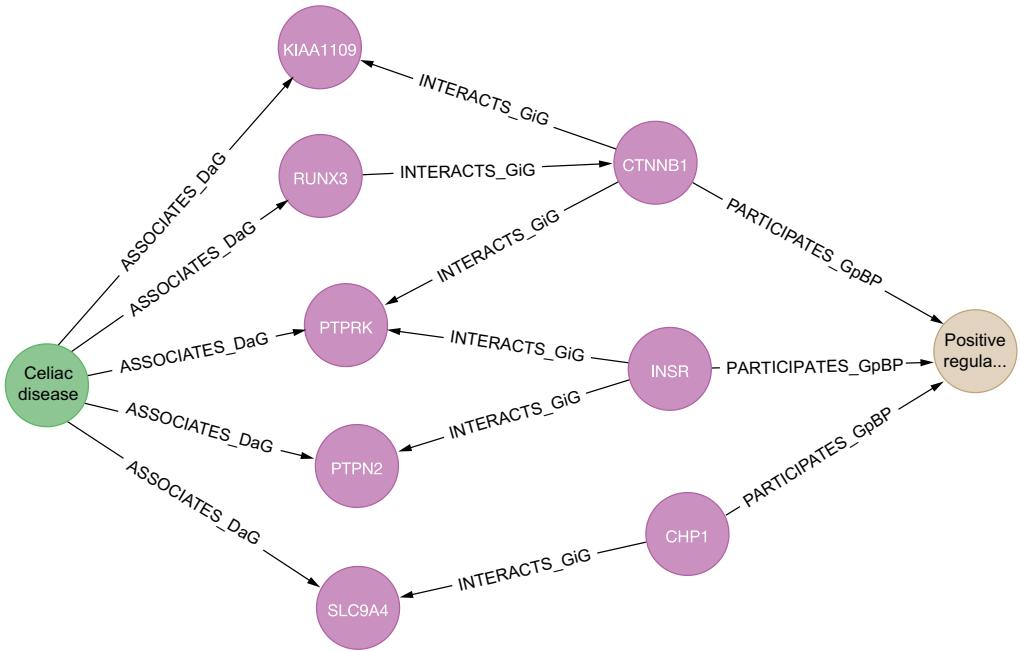

*그림 4.11 — 책 Listing 4.19 질의의 결과. 셀리악병과 "당단백질 생합성 과정의 양성 조절" 사이의 경로들이다. DWPC 라는 하나의 숫자 뒤에 이런 구체적 경로들이 있다는 것을 보여준다 — 순위표만 보고 끝내지 않고 근거까지 추적할 수 있어야 실제 연구에 쓸 수 있다.*

### 실습 4-C — 해설판 4.3.1 의 연습문제

> 질의를 조금 바꾸면 다른 질병에 대해서도 같은 분석을 할 수 있습니다. 몇 가지를 실행해 보고 조사도 해 보면서, 이 지식 그래프가 얼마나 많은 지식을 담고 있는지 평가해 보세요.

아래 셀이 질병 이름만 바꿔 4.17 을 재실행한다. 자가면역 질환 세 개를 비교하면 DWPC 순위가 질병마다 다른 면역 경로를 집어내는 것을 볼 수 있다.

In [12]:
"""실습 4-C 풀이 — 질병을 바꿔 4.17 을 재실행하고 상위 과정을 비교한다.

책 4.17 은 질병 이름이 질의에 하드코딩돼 있다. 파라미터로 바꿔 여러 질병에 돌린다.
"""
DISEASES = ["celiac disease", "multiple sclerosis", "rheumatoid arthritis", "type 1 diabetes mellitus"]

PARAMETERIZED = """
MATCH path = (n0:Disease)-[:ASSOCIATES_DaG]-(n1)-[:PARTICIPATES_GpBP]-(n2:BiologicalProcess)
WHERE n0.name = $disease
WITH [
  size([(n0)-[:ASSOCIATES_DaG]-() | n0]),
  size([()-[:ASSOCIATES_DaG]-(n1) | n1]),
  size([(n1)-[:PARTICIPATES_GpBP]-() | n1]),
  size([()-[:PARTICIPATES_GpBP]-(n2) | n2])
] AS degrees, path, n2
WITH n2.name AS go_name, count(path) AS PC,
     sum(reduce(pdp = 1.0, d in degrees | pdp * d ^ -0.4)) AS DWPC,
     size([(n2)-[:PARTICIPATES_GpBP]-() | n2]) AS n_genes
WHERE n_genes >= 5 AND PC >= 2
RETURN go_name, PC, DWPC, n_genes ORDER BY DWPC DESC LIMIT 3
"""

with cypher.driver() as drv, drv.session(database="hetionet") as s:
    for disease in DISEASES:
        genes = s.run("MATCH (d:Disease {name:$d})-[:ASSOCIATES_DaG]-(g) "
                      "RETURN count(DISTINCT g) AS n", d=disease).single()["n"]
        if genes == 0:
            print(f"\n{disease}: Hetionet 에 없다 (표기 확인 필요)")
            continue
        print(f"\n=== {disease}  (연관 유전자 {genes}개) ===")
        for r in s.run(PARAMETERIZED, disease=disease).data():
            print(f"    DWPC {r['DWPC']:.5f}  PC {r['PC']:>3}  유전자 {r['n_genes']:>4}  {r['go_name'][:46]}")

print("\n-> 질병마다 상위 과정이 다르다. 같은 지식 그래프·같은 지표인데도 질병 특이적인")
print("   면역 경로가 집어지는 것이 DWPC 가 '유명한 노드' 를 누른 결과다.")


=== celiac disease  (연관 유전자 48개) ===
    DWPC 0.03347  PC  10  유전자   75  T cell costimulation
    DWPC 0.03330  PC  10  유전자   76  lymphocyte costimulation
    DWPC 0.03277  PC   3  유전자   12  tolerance induction

=== multiple sclerosis  (연관 유전자 150개) ===


    DWPC 0.04502  PC  40  유전자  207  positive regulation of leukocyte cell-cell adh
    DWPC 0.04438  PC  39  유전자  201  positive regulation of T cell activation
    DWPC 0.04422  PC  50  유전자  381  regulation of lymphocyte activation

=== rheumatoid arthritis  (연관 유전자 267개) ===


    DWPC 0.07244  PC   2  유전자    5  protein side chain deglutamylation
    DWPC 0.06003  PC   2  유전자    8  protein deglutamylation
    DWPC 0.05930  PC  99  유전자  880  positive regulation of immune system process

=== type 1 diabetes mellitus  (연관 유전자 131개) ===
    DWPC 0.03578  PC  48  유전자  991  regulation of immune response
    DWPC 0.03430  PC  29  유전자  431  response to drug
    DWPC 0.03117  PC  39  유전자  805  response to cytokine

-> 질병마다 상위 과정이 다르다. 같은 지식 그래프·같은 지표인데도 질병 특이적인
   면역 경로가 집어지는 것이 DWPC 가 '유명한 노드' 를 누른 결과다.


---
### 4.3.2 LLM 으로 경로 분석 결과 해석하기 — 숫자를 이야기로

DWPC 질의는 생물학적 과정을 **정량적으로 순위** 매겨준다. 하지만 그 결과를 실제로 쓸 수 있는 통찰로 바꾸려면 도메인 전문성과 맥락적 이해가 필요하다. 여기서 LLM 이 해석자 역할을 한다 — 1장의 비유로 돌아가면, **사실 대장이 뽑아낸 딱딱한 순위표를 달변가가 서사로 풀어주는 것** 이다.

**책 Listing 4.20 은 저장소에 코드 파일이 없다.** 프롬프트 리스팅이기 때문이다. 해설판 본문에서 가져왔다.

```text
You are a biomedical research assistant analyzing gene ontology pathway enrichment
results for celiac disease. Please interpret the following results from a knowledge
graph analysis and provide insights for clinical researchers:

QUERY RESULTS:
- T cell costimulation (DWPC: 0.03347, PC: 10, Genes: 75)
- lymphocyte costimulation (DWPC: 0.03329, PC: 10, Genes: 76)
- positive regulation of T cell activation (DWPC: 0.02925, PC: 14, Genes: 201)
- positive regulation of glycoprotein biosynthetic process
  (DWPC: 0.00342, PC: 6, Genes: 17)

CONTEXT: These pathways were identified through DWPC analysis of celiac
disease-associated genes in a protein-protein interaction network. DWPC scores
indicate pathway relevance while accounting for node degree bias.

ANALYSIS REQUEST:
1. Interpret the biological significance of these top-ranked pathways in celiac disease
2. Explain the relationship between these processes and celiac disease pathogenesis
3. Identify potential therapeutic implications
4. Highlight any unexpected findings that warrant further investigation
5. Suggest follow-up research questions based on these results
```

프롬프트의 구조를 보면 세 부분이다 — **역할 부여**(biomedical research assistant), **데이터 제시**(DWPC·PC·유전자 수를 그대로), **작업 명세**(5가지 요청). 데이터에 DWPC 뿐 아니라 PC 와 유전자 수를 함께 주는 것이 중요하다. LLM 이 "PC 는 높은데 DWPC 는 낮다" 같은 대비를 읽어야 하기 때문이다.

> **⚠️ 아래 셀은 LLM API 를 호출하지 않는다.** 4.17·4.18 의 **실제 실행 결과** 로 프롬프트를 조립해 출력만 한다. 이유가 두 가지다. 첫째 API 키와 비용이 필요해 재현성을 떨어뜨린다. 둘째 책에 실린 값을 그대로 쓰면 현재 데이터와 어긋난다 — 프롬프트는 **내가 방금 얻은 숫자** 로 만들어야 의미가 있다. 출력된 프롬프트를 쓰고 싶은 LLM 도구에 붙여넣어 직접 실습하라.

> **책이 실은 Claude.ai 해석은 가설이다.** 해설판은 T세포 공동자극이 셀리악병의 자가면역적 성질과 어떻게 연결되는지, 관용 유도가 왜 교란된 것으로 보이는지를 설명한 예시 출력을 싣고 있다. 이는 **연구 가설 생성** 이며 임상적 사실이나 진료 권고가 아니다. 해설판 자신도 "의사와 연구자의 적절한 해석 없이 LLM 결과를 그대로 쓰는 것을 권하지 않는다" 고 못박는다.

In [13]:
"""책 4.20 — 실제 실행 결과로 LLM 프롬프트를 조립한다. API 는 호출하지 않는다.

책은 집필 시점 값을 프롬프트에 하드코딩했다. 여기서는 위 4.17·4.18 셀이 방금 얻은
결과를 쓴다. 데이터가 갱신되면 프롬프트도 함께 갱신되어야 의미가 있다.
"""
top_basic = sorted(enrich, key=lambda r: -r["DWPC"])[:3]
top_refined = [r for r in sorted(refined, key=lambda r: -r["DWPC"])
               if r["go_id"] not in {x["go_id"] for x in top_basic}][:2]

lines = [f"- {r['go_name']} (DWPC: {r['DWPC']:.5f}, PC: {r['PC']}, Genes: {r['n_genes']})"
         for r in top_basic + top_refined]

PROMPT = f"""You are a biomedical research assistant analyzing gene ontology pathway
enrichment results for celiac disease. Please interpret the following results from a
knowledge graph analysis and provide insights for clinical researchers:

QUERY RESULTS:
{chr(10).join(lines)}

CONTEXT: These pathways were identified through DWPC analysis of celiac
disease-associated genes in a protein-protein interaction network (Hetionet).
DWPC scores indicate pathway relevance while accounting for node degree bias.
Damping exponent w = 0.4.

ANALYSIS REQUEST:
1. Interpret the biological significance of these top-ranked pathways in celiac disease
2. Explain the relationship between these processes and celiac disease pathogenesis
3. Identify potential therapeutic implications
4. Highlight any unexpected findings that warrant further investigation
5. Suggest follow-up research questions based on these results

Treat your output as hypothesis generation for researchers, not clinical guidance."""

print(PROMPT)
print("\n" + "=" * 78)
print("위 프롬프트를 쓰고 싶은 LLM 에 직접 붙여넣어라. 이 노트북은 API 를 호출하지 않는다.")
print("마지막 문장을 넣은 이유: 책의 예시 출력은 연구 가설이지 임상 권고가 아니다.")

You are a biomedical research assistant analyzing gene ontology pathway
enrichment results for celiac disease. Please interpret the following results from a
knowledge graph analysis and provide insights for clinical researchers:

QUERY RESULTS:
- T cell costimulation (DWPC: 0.03347, PC: 10, Genes: 75)
- lymphocyte costimulation (DWPC: 0.03330, PC: 10, Genes: 76)
- tolerance induction (DWPC: 0.03277, PC: 3, Genes: 12)
- positive regulation of glycoprotein biosynthetic process (DWPC: 0.00343, PC: 6, Genes: 17)
- negative regulation of osteoblast proliferation (DWPC: 0.00342, PC: 4, Genes: 9)

CONTEXT: These pathways were identified through DWPC analysis of celiac
disease-associated genes in a protein-protein interaction network (Hetionet).
DWPC scores indicate pathway relevance while accounting for node degree bias.
Damping exponent w = 0.4.

ANALYSIS REQUEST:
1. Interpret the biological significance of these top-ranked pathways in celiac disease
2. Explain the relationship between these

---
## 4.4 임상 응용 — 정밀 의료를 향하여

임상 응용은 아직 지식 그래프 활용의 **초기 단계** 다. 장기 목표는 **정밀 의료** — 한 사람의 유전·환경·생활 습관이 질병 예방·치료의 최선책을 정하는 데 어떻게 기여하는지 이해하는 것 — 를 뒷받침하는 것이다.

이를 구현하려면 오믹스 데이터를 **전자 건강 기록(EHR)** 이 포함된 임상 의사결정 과정에 통합해야 한다. 걸림돌이 셋이다. 생명의학 데이터의 양과 다양성, 임상적으로 중요한 지식이 여러 데이터베이스와 논문에 흩어져 있다는 점, 그리고 **프라이버시** 다.

EHR 자체도 까다롭다. 해석에 상당한 주관성이 개입하고, 임상의가 무관하다고 판단한 정보는 누락돼 정보 결손이 생긴다.

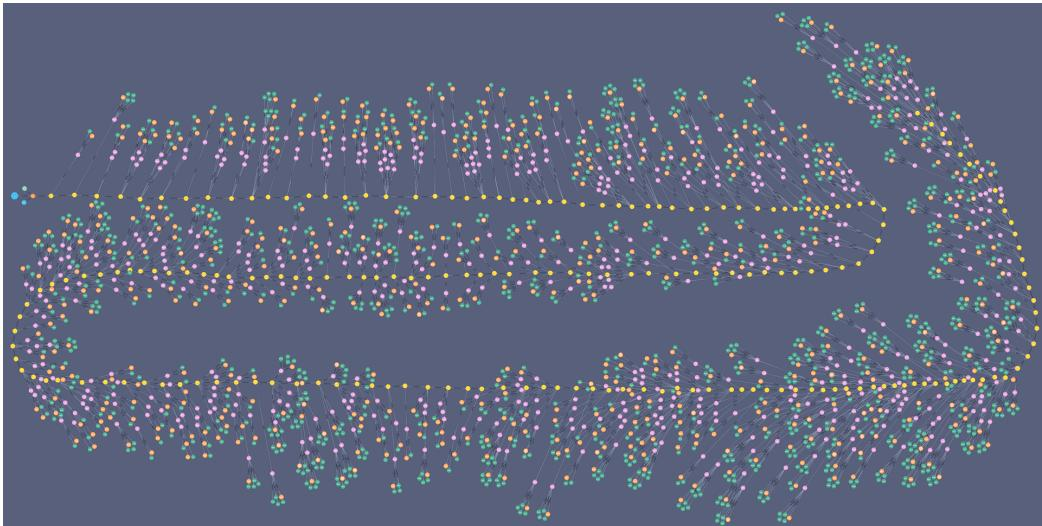

*그림 4.12 — 한 환자의 임상 종양학 여정. **환자 여정 지도(patient journey mapping)** 는 사람들이 어떻게 의료 서비스에 들어오고 겪고 나가는지를 이해하는 접근이다. 특정 질병의 표준 진료를 규정하는 **임상 경로(clinical pathway)** 와 짝을 이룬다.*

프라이버시 해법으로 두 접근이 있다. 하나는 방대한 환자 데이터에서 **통계 정보만 추출** 해 그래프에 저장하고 실제 환자 데이터는 저장하지 않는 것이다. 다른 하나는 비민감·익명화 데이터로 **신원 식별 정보를 제거한 일반적 임상 지식 그래프** 를 만들고, 환자 EHR 은 꼭 필요할 때 동의를 얻어 쓰는 것이다.

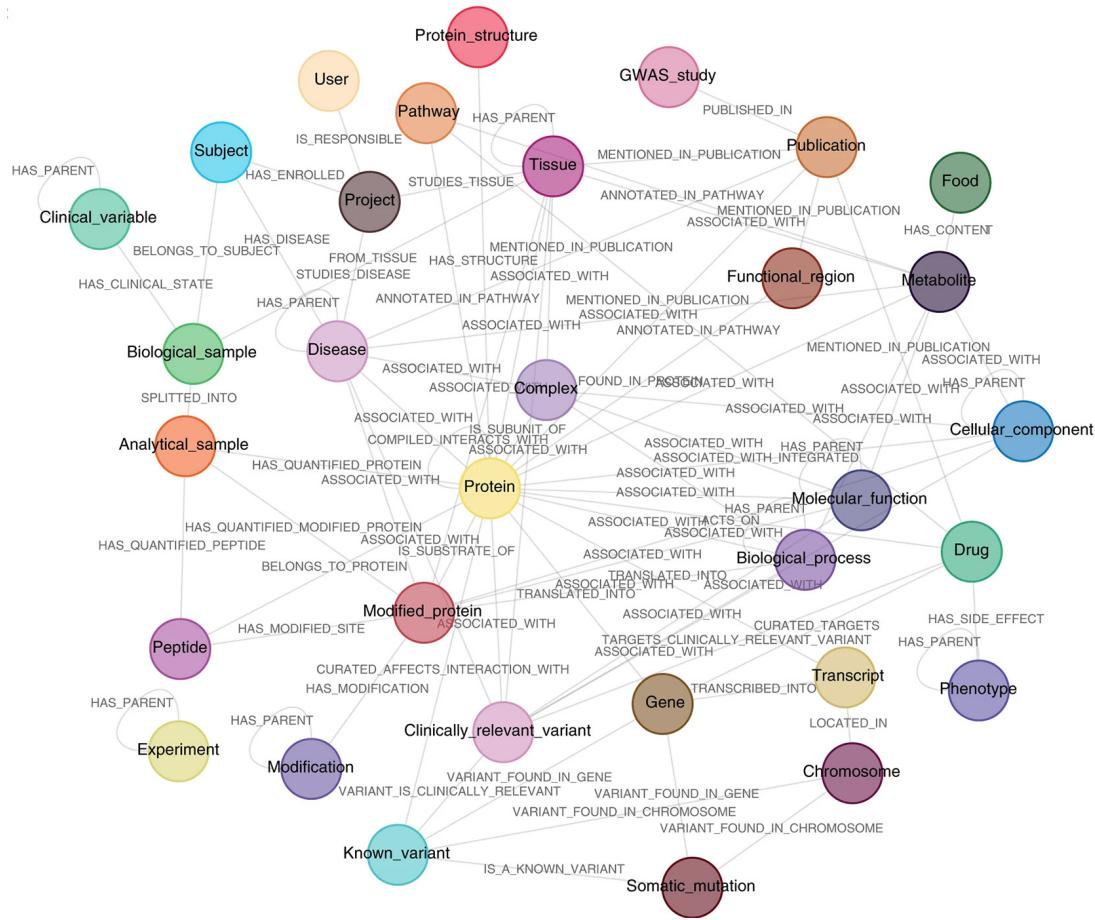

*그림 4.13 — **임상 지식 그래프(Clinical Knowledge Graph, CKG)** 의 스키마. 노드 레이블 33개를 관계 51종으로 연결해 데이터를 조화·통합한다. 변경된 기능에 대한 통찰, 조절된 단백질에 대한 약물 제안, 있을 수 있는 교란 요인 노출 같은 질의가 가능해진다.*

> **⚠️ 리스팅 번호 주의.** 여기서 책과 저장소가 어긋난다.
>
> | 책 | 내용 | 저장소 파일 |
> | --- | --- | --- |
> | 4.21 | Importing the CKG database | `4.20 Importing CKG database` |
> | 4.22 | Finding known protein–disease associations | `4.21 Known protein to disease association` |
> | 4.23 | Example LLM clinical analysis prompt | 없음 (해설판 본문) |
>
> 책 4.20 이 코드 없는 프롬프트 리스팅이라 그 뒤가 한 칸씩 밀렸다. `study.toml` 의 `[mapping.listings.ch04]` 가 이 대응의 정본이다.

### `ckg` 는 선택 사항이다

CKG 는 **노드 1,860만 · 관계 2억 6백만** 규모이고 시드 백업이 **5.1GB**, 마이그레이션에 약 5분 걸린다. 이걸 쓰는 리스팅은 4.21(생성)·4.22(질의) 둘뿐이므로 `RUN_CKG = False` 면 건너뛴다. 아래 셀은 건너뛸 때도 **내가 실제로 실행해 얻은 결과** 를 보여주므로 무엇이 나오는지 알 수 있다.

In [14]:
"""책 4.21 + 4.22 — CKG 생성과 단백질-질병 연관 질의.

시나리오: 임상 연구가 어떤 단백질 집합을 표적으로 삼고 임상시험을 계획 중이다.
대상 환자 일부가 심근병증 관련 질병을 앓고 있어, 표적 단백질과 심근병증 사이에
알려진 연관성이 있는지 확인하려 한다.

4.22 의 핵심은 HAS_PARENT*0.. 이다. 심근병증(DOID:0050700) 의 모든 하위 질병까지
거슬러 올라가 매칭한다. 질병 온톨로지 계층을 쓰는 3장 3.27 의 추론과 같은 발상이다.
"""
# RUN_CKG=False 일 때 보여줄 실측 결과 (2026-07 Enterprise 5.26.28 에서 직접 실행)
MEASURED = [
    ("ACTC1~P68032", "cardiomyopathy <DOID:0050700>", 5.0),
    ("ACTC1~P68032", "intrinsic cardiomyopathy <DOID:0060036>", 5.0),
    ("ACTC1~P68032", "restrictive cardiomyopathy <DOID:397>", 5.0),
    ("ACTC1~P68032", "hypertrophic cardiomyopathy <DOID:11984>", 5.0),
]

show("4.22")

if not RUN_CKG:
    print("\nRUN_CKG = False — ckg 생성을 건너뛴다 (시드 5.1GB · 마이그레이션 약 5분).")
    print("아래는 실제로 실행해 얻은 결과다 (책 표 4.5 와 대조):\n")
    print(f"    {'node1':<16}{'node2':<46}{'weight':>7}")
    for node1, node2, weight in MEASURED:
        print(f"    {node1:<16}{node2:<46}{weight:>7}")
    print("\n  -> ACTC1 하나가 여러 유형의 내인성 심근병증과 강하게 연관된다(score 5.0).")
    print("     책 표 4.5 도 같은 단백질을 보여준다. 이 발견이 후속 조사의 출발점이 된다.")
    print("\n  RUN_CKG = True 로 바꾸고 이 셀을 다시 실행하면 직접 확인할 수 있다.")
else:
    with cypher.driver() as drv, drv.session(database="system") as s:
        already = s.run("SHOW DATABASES YIELD name RETURN collect(DISTINCT name) AS n").single()["n"]
    if "ckg" not in already:
        print("\n생성 중 — 5.1GB 를 받아 5.4.0 백업을 현재 버전으로 마이그레이션한다. 약 5분...")
        for statement in statements("4.21"):
            with cypher.driver() as drv, drv.session(database="system") as s:
                s.run(statement).consume()
        elapsed = wait_online("ckg", timeout=900)
        print(f"online ({elapsed:.1f}초)" if elapsed else "타임아웃")
    print("ckg 규모:", {k: f"{v:,}" for k, v in db_stats("ckg").items()})
    print()
    run("4.22", "ckg", limit=8)

── 책 Listing 4.22  (파일 4.21) ──
WITH
  ['A1BG~P04217','A2M~P01023','ACACB~O00763',
   'ACTC1~P68032','ADIPOQ~Q15848','AGT~P01019',
   'AIFM2~Q9BRQ8','APOA2~V9GYM3'] as  proteins,
  3 as minScore,
  "DOID:0050700" as parentDisease
MATCH (protein:Protein)-[r]-(disease:Disease)
WHERE (
  (protein.name+"~"+protein.id) IN proteins) AND
  toFloat(r.score)> minScore  AND
  ((disease)-[:HAS_PARENT*0..]->(:Disease {id: parentDisease}))
RETURN
  (protein.name+"~"+protein.id) AS node1,
  disease.name+" <"+disease.id+">" AS node2,
  r.score AS weight, type(r) AS type,
  r.source AS source
ORDER BY weight DESC

RUN_CKG = False — ckg 생성을 건너뛴다 (시드 5.1GB · 마이그레이션 약 5분).
아래는 실제로 실행해 얻은 결과다 (책 표 4.5 와 대조):

    node1           node2                                          weight
    ACTC1~P68032    cardiomyopathy <DOID:0050700>                     5.0
    ACTC1~P68032    intrinsic cardiomyopathy <DOID:0060036>           5.0
    ACTC1~P68032    restrictive cardiomyopathy <DOID:397>             5.0
    A

### 4.4.1 LLM 기반 임상 의사결정 지원 — 발견을 진료로 잇다

CKG 분석이 ACTC1 과 여러 심근병증 사이의 강한 연관성을 찾아냈다. **책 Listing 4.23** 은 이를 임상적 맥락으로 옮기는 프롬프트다. 4.20 과 마찬가지로 코드 파일이 없어 해설판 본문에서 가져왔다.

```text
You are a clinical informatics specialist analyzing protein-disease associations from
electronic health records integrated with biomedical knowledge graphs. Provide clinical
decision support based on these findings:

CLINICAL SCENARIO: Research study targeting proteins in patients with
cardiomyopathy-related diseases

KNOWLEDGE GRAPH FINDINGS:
- ACTC1~P68032 shows strong associations (score: 5.0) with:
  * Intrinsic cardiomyopathy (DOID:0060036)
  * Left ventricular noncompaction (DOID:0060480)
  * Familial hypertrophic cardiomyopathy (DOID:0080326)
  * Hypertrophic cardiomyopathy (DOID:11984)
  * Dilated cardiomyopathy (DOID:12930)
  * Restrictive cardiomyopathy (DOID:397)

TARGET PROTEIN LIST:
['A1BG~P04217','A2M~P01023','ACACB~O00763','ACTC1~P68032','ADIPOQ~Q15848',
 'AGT~P01019','AIFM2~Q9BRQ8','APOA2~V9GYM3']

CLINICAL REQUEST:
1. Interpret the clinical significance of ACTC1's broad cardiomyopathy associations
2. What does this suggest about patient stratification for clinical trials?
3. Identify potential safety considerations for the research study
4. Recommend additional screening or monitoring protocols
5. Suggest companion biomarkers or genetic testing approaches
6. Propose modifications to inclusion/exclusion criteria based on these findings
```

4.20 과 결정적으로 다른 점이 있다. 4.20 은 **연구 가설** 을 물었지만 4.23 은 **환자 층화·안전성·선별 프로토콜·포함/제외 기준** 을 묻는다. 즉 사람에게 영향을 주는 영역이다.

> **⚠️ 이 노트북은 4.23 을 실행하지 않는다.** 프롬프트 원문만 싣는다. 세 가지 이유다.
>
> 첫째, **해설판 자신이 경고한다** — "의사와 연구자의 적절한 해석 없이 LLM 의 결과를 그대로 사용하는 것을 권하지 않습니다." 목표는 사람을 대체하는 게 아니라 역량을 키우는 것이다.
>
> 둘째, 이 프롬프트가 요구하는 것(임상시험 포함/제외 기준, 모니터링 프로토콜)은 **자격 있는 임상의의 판단 영역** 이다. LLM 출력을 노트북에 실어두면 그것이 검증된 권고로 읽힐 위험이 있다.
>
> 셋째, 실제 EHR 을 다룬다면 **환자 개인정보** 가 프롬프트에 들어간다. 위 예시는 단백질·질병 식별자뿐이지만, 실무에서 이 패턴을 쓸 때는 프라이버시 검토가 선행돼야 한다.
>
> 프롬프트 설계를 학습하는 것이 목적이라면 위 원문을 읽고 구조를 분석하면 충분하다. 직접 실행해 보려면 **결과를 가설로만 다루고 임상 판단으로 쓰지 말라.**

---
## 요약

해설판이 정리한 이 장의 핵심 여섯 가지다.

- 구조화된 소스로 만든 KG 는 이질적 데이터셋을 체계적으로 통합해야 한다 — **엔티티 해소 · 스키마 정렬 · 데이터 품질 검증**. 이 노트북에서 `ppi` 의 `Celiac Disease` 와 `hetionet` 의 `celiac disease` 표기 차이로 그 필요성을 직접 봤다

- **WCC · Louvain** 같은 군집화는 다중 소스 KG 의 전체 구조와 커뮤니티 조직을 보여준다

- **밀도 · 전도도 · 가장 큰 연결 컴포넌트** 같은 부분 그래프 지표는 도메인을 가리지 않고 KG 의 품질과 완결성을 정량 평가한다

- **DWPC** 같은 경로 기반 지표는 단순한 경로 세기보다 정교하다. 아무하고나 연결된 노드를 자동으로 눌러 특이한 연결을 드러낸다

- **Hetionet · PPI · CKG** 는 통합 기법과 분석 접근을 시연하기 좋은 시험대다

- KG 분석 결과에 대한 **LLM 해석** 은 정량 지표를 도메인 통찰과 연구 가설로 옮긴다. 임상 판단으로 쓰지는 않는다

### 이 노트북에서 실측한 수치

| 항목 | 실측값 | 책 값 |
| --- | --- | --- |
| `ppi` 노드 / 관계 | 23,073 / 363,711 | 단백질 21,559 · 상호작용 342,354 |
| `hetionet` 노드 / 관계 | 47,031 / 2,250,197 | 47,031 / 2,250,197 (일치) |
| `ckg` 노드 / 관계 | 18,606,441 / 205,971,182 | 노드 레이블 33 · 관계 51종 |
| PPI 연결 컴포넌트 (WCC) | 27개 | — |
| Louvain 커뮤니티 / 모듈성 | 42개 / 0.3951 | — |
| 셀리악병 연관 유전자 (Hetionet) | 48개 | 48개 (일치) |
| 셀리악병 질병 경로 컴포넌트 | 50개 | 전체 중앙값 16 |
| 셀리악병 밀도 / 전도도 | 0.0101 / 0.9710 | 중앙값 0.07 / 0.96 |
| 4.17 최상위 DWPC | T cell costimulation 0.03347 | 0.03347 (일치) |

DWPC 값과 Hetionet 규모는 책과 **정확히 일치** 한다. 백업 시드가 책 집필 시점 스냅샷이기 때문이다. 반면 `ppi` 는 시드가 4.2\~4.5 를 이미 거친 상태라 단백질 수가 책 본문의 원시 수치와 다르다.

### 시드 다운로드 비용

| DB | 시드 | 생성 시간 | 필수 |
| --- | --- | --- | --- |
| `ppi` | 7 MB | 5초 | ✅ |
| `hetionet` | 69 MB | 8초 | ✅ |
| `ckg` | 5.1 GB | 약 5분 | ⬜ (4.21·4.22 만) |

### 핵심 용어

| 용어 | 뜻 |
| --- | --- |
| 지능형 자문 시스템 (IAS) | KG 등을 활용해 사람의 의사결정을 돕는 조언 시스템 |
| 다중 오믹스 (multi-omic) | 유전체·전사체·단백질체 등을 함께 쓰는 분석 접근 |
| 질병 경로 (disease pathway) | 질병 연관 단백질 집합으로 정의되는 PPI 네트워크의 부분 그래프 |
| 경로 경계 (pathway boundary) | 질병 경로 안과 밖을 잇는 엣지 집합 $B_d$ |
| 전도도 (conductance) | 부분 그래프가 나머지로부터 얼마나 독립적인가. 낮을수록 독립적 |
| 단일 분할 / 이분 그래프 | 한 종류 노드끼리 / 두 종류 노드 사이의 연결 |
| 메타그래프 (metagraph) | 데이터베이스 구조(노드·관계 유형)의 묘사 |
| 메타경로 (metapath) | 경로의 묘사. 노드·관계 유형의 시퀀스 |
| PC (Path Count) | 메타경로에 해당하는 경로 개수. 연결도를 보정하지 않는다 |
| PDP (Path-Degree Product) | 경로의 차수들을 $-w$ 승 해 곱한 값 |
| DWPC | 메타경로에 속한 모든 경로의 PDP 합 |
| 감쇠 지수 (damping exponent) | $w$. 클수록 연결 많은 노드를 지나는 경로를 더 깎는다 |
| 약물 재활용 (drug repurposing) | 승인된 약물의 새 용도를 찾아 개발 기간·비용·실패율을 줄이는 접근 |
| 정밀 의료 (precision medicine) | 개인의 유전·환경·생활습관으로 예방·치료 최선책을 정하는 접근 |
| DOID | 질병 온톨로지 식별자 |

### 참고 링크

- [교재 4장 해설판 (한국어)](../../04_from_simple_networks_to_multisource_integration_ko_explained.md)

- [원서 저장소 chapters/ch04](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch04)

- [Hetionet (het.io)](https://het.io/)

- [SNAP — Disease Pathways in the Human Interactome](http://snap.stanford.edu/pathways/)

- [Clinical Knowledge Graph (MannLabs/CKG)](https://github.com/MannLabs/CKG)

- [Neo4j Graph Data Science 문서](https://neo4j.com/docs/graph-data-science/current/)

### 다음 장으로

3장은 온톨로지 하나로 KG 를 지었고, 4장은 여러 구조화 소스를 합쳤다. **5장(저장소 [`ch07`](../../../chapter_05_extracting_domain_specific_knowledge_from_unstructured_data/src/ch07))** 은 방향이 바뀐다 — **비정형 데이터에서 지식을 추출** 한다. 이 장에서 LLM 이 해석자 역할만 했던 것과 달리, 5장부터 LLM 이 구축 파이프라인의 핵심 부품이 된다.

주의: 5장의 저장소 디렉터리는 `ch07` 이다. MEAP 번호라 어긋난다. 확인 근거는 `openai` 가 책 5장에 14회, `GPT output` 이 3회 나오는 것이다.